In [2]:
import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from captum.attr import IntegratedGradients

import matplotlib.pyplot as plt
import seaborn as sns


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

import quantus

from paths import (
    DATASETS_DIR,
    MULTIMODAL_RET_DIR,
    vision_emb_path,
    text_emb_path,
    projection_matrix_path,
    projected_emb_path,
)

DATASET = "Flickr8k"
device = "cuda" if torch.cuda.is_available() else "cpu"

VISION_MODELS = ["ResNet50", "MobileNetV3", "ViT", "PVT"]
TEXT_MODELS   = ["GPT2", "BERT", "RoBERTa"]
PROJECTIONS   = ["RP", "CPCA", "WCCA"]
FUSIONS       = ["add", "gated", "mul"]
TASKS = {
    "i2t": {"needs_fusion": False},
    "t2i": {"needs_fusion": False},
    "m2t": {"needs_fusion": True},
    "m2i": {"needs_fusion": True},
}


/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [5]:
proj_all = {}

for v in VISION_MODELS:
    for t in TEXT_MODELS:
        for method in PROJECTIONS:

            Wv_path = projection_matrix_path(DATASET, v, t, method, "Wv")
            Wt_path = projection_matrix_path(DATASET, v, t, method, "Wt")
            Xv_path = projected_emb_path(DATASET, v, t, method, "Xv")
            Xt_path = projected_emb_path(DATASET, v, t, method, "Xt")

            if not (os.path.exists(Wv_path) and os.path.exists(Wt_path)):
                continue

            # Load projection matrices
            Wv = np.load(Wv_path)
            Wt = np.load(Wt_path)

            # Load projected image embeddings
            Xv_proj = np.load(Xv_path)  # (8000, d)

            # Load projected caption embeddings (UNGROUPED)
            Xt_proj_full = np.load(Xt_path)  # (40000, d)

            # Group AFTER projection
            Xt_proj_grouped = group_captions(Xt_proj_full, k=5)  # (8000, d)

            proj_all[(v, t, method)] = {
                "Wv": Wv,
                "Wt": Wt,
                "Xv": Xv_proj,
                "Xt_full": Xt_proj_full,         # UNGROUPED
                "Xt_grouped": Xt_proj_grouped,   # GROUPED
            }

print("Loaded projection configs:", len(proj_all))


def fuse_add(xv, xt):
    return xv + xt

def fuse_gated(xv, xt, alpha=0.5):
    return alpha * xv + (1 - alpha) * xt

def fuse_mul(xv, xt):
    return xv * xt

FUSION_FUNCS = {
    "add": fuse_add,
    "gated": fuse_gated,
    "mul": fuse_mul,
}

model_pairs = [
    ("ViT", "BERT"),
    ("ViT", "RoBERTa"),
    ("ResNet50", "BERT")
]


methods = ["RP", "CPCA", "WCCA"]
colors = {"RP": "tab:blue", "CPCA": "tab:orange", "WCCA": "tab:green"}

Loaded projection configs: 36


In [6]:
print(projection_matrix_path(DATASET, "ViT", "BERT", "RP", "Wv"))

TFE_Data/Model_Artifacts/projections/Flickr8k/ViT_BERT/RP/Wv.npy


In [6]:
def load_top50(dataset, v, t, method, task):
    """
    Loads top-50 retrieval results for:
    - RP / CPCA / WCCA
    - SOTA models (OpenCLIP, CLIP)
    - unimodal and multimodal tasks
    """

    # ------------------------------------------------------------
    # 1. SOTA fallback (unimodal + multimodal)
    # ------------------------------------------------------------
    sota_fname = f"fix_top50_{v}_{t}_sota_{task}.json"
    sota_path = os.path.join(MULTIMODAL_RET_DIR, sota_fname)
    
    if v == "OpenCLIPL14": 
        v = "OpenCLIP"
        t = "OpenCLIP"

    if os.path.exists(sota_path):
        with open(sota_path, "r") as f:
            return json.load(f)

    # ------------------------------------------------------------
    # 2. Projection-based models (RP, CPCA, WCCA)
    # ------------------------------------------------------------
    if task in ["i2t", "t2i"]:
        fname = f"fix_top50_{v}_{t}_{method}_{task}.json"
    else:
        base_task, fusion = task.split("_")
        fname = f"fix_top50_{v}_{t}_{method}_{base_task}_{fusion}.json"

    path = os.path.join(MULTIMODAL_RET_DIR, fname)

    if not os.path.exists(path):
        return None

    with open(path, "r") as f:
        return json.load(f)


def cosine_sim(a, b):
    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)
    return (a * b).sum(dim=-1)  # ()




In [7]:
def ig_on_embedding(x_input, x_fixed, steps=50, baseline=None):
    """
    x_input: torch.Tensor (d,) - the variable embedding
    x_fixed: torch.Tensor (d,) - the fixed counterpart
    returns: torch.Tensor (d,) - IG attribution over dimensions
    """
    x_input = x_input.to(device)
    x_fixed = x_fixed.to(device)

    if baseline is None:
        baseline = torch.zeros_like(x_input)

    def forward_fn(x):
        # x: (1, d)
        return cosine_sim(x, x_fixed.unsqueeze(0))

    ig = IntegratedGradients(forward_fn)
    attr = ig.attribute(
        x_input.unsqueeze(0),
        baselines=baseline.unsqueeze(0),
        n_steps=steps
    )  # (1, d)
    
    return attr.squeeze(0).detach().cpu()


def ig_i2t(Xv_proj, Xt_full_proj, i, j, steps=50):
    xv_i = torch.tensor(Xv_proj[i], dtype=torch.float32)
    xt_j = torch.tensor(Xt_full_proj[j], dtype=torch.float32)
    return ig_on_embedding(xv_i, xt_j, steps=steps)


def ig_t2i(Xv_proj, Xt_full_proj, i, j, steps=50):
    xv_i = torch.tensor(Xv_proj[i], dtype=torch.float32)
    xt_j = torch.tensor(Xt_full_proj[j], dtype=torch.float32)
    return ig_on_embedding(xt_j, xv_i, steps=steps)

def ig_m2t(Xv_proj, Xt_grouped_proj, Xt_full_proj, i, j, fusion="add", steps=50):
    F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[i], Xt_grouped_proj[i]), dtype=torch.float32)
    xt_j = torch.tensor(Xt_full_proj[j], dtype=torch.float32)
    return ig_on_embedding(F_i, xt_j, steps=steps)

def ig_m2i(Xv_proj, Xt_grouped_proj, i, j, fusion="add", steps=50):
    F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[i], Xt_grouped_proj[i]), dtype=torch.float32)
    xv_j = torch.tensor(Xv_proj[j], dtype=torch.float32)
    return ig_on_embedding(F_i, xv_j, steps=steps)


In [8]:
def compute_i2t_ig_for_all_projections(v, t, img_idx, cap_idx, steps=50):
    ig_dict = {}

    for method in ["RP", "CPCA", "WCCA"]:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_full"]

        ig = ig_i2t(Xv_proj, Xt_proj, img_idx, cap_idx, steps=steps)
        ig_dict[method] = ig

    return ig_dict


In [9]:
def ig_m2t(Xv_proj, Xt_proj, i, j, fusion="add", steps=50):
    xv_i = torch.tensor(Xv_proj[i], dtype=torch.float32)
    xt_i = torch.tensor(Xt_proj[i], dtype=torch.float32)  # same index for fusion
    xt_j = torch.tensor(Xt_proj_full[j], dtype=torch.float32)

    F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[i], Xt_proj[i]), dtype=torch.float32)
    return ig_on_embedding(F_i, xt_j, steps=steps)


def ig_m2i(Xv_proj, Xt_proj, i, j, fusion="add", steps=50):
    xv_i = torch.tensor(Xv_proj[i], dtype=torch.float32)
    xt_i = torch.tensor(Xt_proj_full[i], dtype=torch.float32)
    xv_j = torch.tensor(Xv_proj[j], dtype=torch.float32)

    F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[i], Xt_proj[i]), dtype=torch.float32)
    return ig_on_embedding(F_i, xv_j, steps=steps)



In [340]:
def plot_ig_bar(attr, title="IG over dimensions", topk=20):
    """
    attr: torch.Tensor (d,)
    """
    a = attr.numpy()
    idx = np.argsort(-np.abs(a))[:topk]
    plt.figure(figsize=(10, 4))
    plt.bar(range(topk), a[idx])
    plt.xticks(range(topk), idx, rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
def plot_ig_bar_comparison(ig_dict, topk=20, title_prefix="IG Comparison"):
    methods = ["RP", "CPCA", "WCCA"]

    plt.figure(figsize=(15, 4))

    for i, method in enumerate(methods):
        ig = ig_dict[method].numpy()
        idx = np.argsort(-np.abs(ig))[:topk]

        plt.subplot(1, 3, i+1)
        plt.bar(range(topk), ig[idx])
        plt.xticks(range(topk), idx, rotation=90)
        plt.title(f"{title_prefix} – {method}")

    plt.tight_layout()
    plt.show()
    
def plot_sorted_abs_ig_curves(ig_dict, title="Sorted |IG| Curves"):
    plt.figure(figsize=(8, 5))

    for method, ig in ig_dict.items():
        sorted_vals = np.sort(np.abs(ig.numpy()))[::-1]
        plt.plot(sorted_vals, label=method)

    plt.title(title)
    plt.xlabel("Dimension rank")
    plt.ylabel("|IG|")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def ig_summary_statistics(ig_dict):
    rows = []

    for method, ig in ig_dict.items():
        arr = ig.numpy()
        rows.append({
            "Method": method,
            "Mean": arr.mean(),
            "Std": arr.std(),
            "Min": arr.min(),
            "Max": arr.max(),
            "L1 Norm": np.abs(arr).sum(),
        })

    df_stats = pd.DataFrame(rows)
    return df_stats

def compute_ig_stats_for_pair(model_pairs, task, img_idx=0, steps=50):
    rows = []

    for i, (v, t) in enumerate(model_pairs):
    # Load top-1 caption index from RP (same top-1 used for all projections)
        top50 = load_top50(DATASET, v, t, "RP", task)
        cap_idx = top50[0]["top50_indices"][0]

        for method in ["RP", "CPCA", "WCCA"]:
            cfg = proj_all[(v, t, method)]
            Xv_proj = cfg["Xv"]
            Xt_proj = cfg["Xt_full"]

            ig = ig_i2t(Xv_proj, Xt_proj, img_idx, cap_idx, steps=steps).numpy()

            rows.append({
                "Vision": v,
                "Text": t,
                "Method": method,
                "Mean": ig.mean(),
                "Std": ig.std(),
                "Min": ig.min(),
                "Max": ig.max(),
                "L1 Norm": np.abs(ig).sum(),
                "Sparsity (L0)": np.sum(np.abs(ig) < 1e-6)
            })

    return rows



In [10]:
def cosine_similarity(a, b):
    a = F.normalize(torch.tensor(a), dim=-1)
    b = F.normalize(torch.tensor(b), dim=-1)
    return (a * b).sum(dim=-1)


In [11]:
def rank_of_target(sim_row, target_idx):
    order = np.argsort(-sim_row)
    loc = np.where(order == target_idx)[0]

    if len(loc) == 0:
        # target not found → assign worst possible rank
        return len(sim_row) + 1

    return int(loc[0]) + 1


def i2t_rank_faithfulness(Xv_proj, Xt_proj, img_idx, cap_idx, ig_attr, k=20):
    """
    Xv_proj: (N_img, d)
    Xt_proj: (N_cap, d)
    img_idx: query image index
    cap_idx: target caption index
    ig_attr: torch.Tensor (d,) IG over image embedding dims
    k: number of top dims to mask
    """

    # 1. Original similarities and rank
    xv = Xv_proj[img_idx]          # (d,)
    sims = cosine_similarity(
        xv.reshape(1, -1),
        Xt_proj
    )[0]                           # (N_cap,)
    orig_rank = rank_of_target(sims, cap_idx)

    # 2. Mask top-k IG dimensions
    a = ig_attr.detach().cpu().numpy()
    topk_idx = np.argsort(-np.abs(a))[:k]

    xv_pert = xv.copy()
    xv_pert[topk_idx] = 0.0

    sims_pert = cosine_similarity(
        xv_pert.reshape(1, -1),
        Xt_proj
    )[0]
    pert_rank = rank_of_target(sims_pert, cap_idx)

    # 3. Rank-based faithfulness score
    rank_drop = pert_rank - orig_rank  # >0 means worse after masking important dims

    return {
        "orig_rank": orig_rank,
        "pert_rank": pert_rank,
        "rank_drop": rank_drop
    }


In [343]:
class RankFaithfulnessMetric:
    """
    Quantus-compatible wrapper for rank-based faithfulness.
    """

    def __init__(self, Xv_proj, Xt_proj, img_idx, cap_idx, ig_attr, k=20):
        self.Xv_proj = Xv_proj
        self.Xt_proj = Xt_proj
        self.img_idx = img_idx
        self.cap_idx = cap_idx
        self.ig_attr = ig_attr
        self.k = k

    def __call__(self, model, x_batch, a_batch, y_batch):
        """
        Quantus passes:
        - model: wrapper model
        - x_batch: perturbed input (ignored)
        - a_batch: attribution (ignored)
        - y_batch: label (ignored)

        We compute rank faithfulness directly.
        """
        result = i2t_rank_faithfulness(
            self.Xv_proj,
            self.Xt_proj,
            self.img_idx,
            self.cap_idx,
            self.ig_attr,
            k=self.k
        )
        return np.array([result["rank_drop"]])


In [12]:
class SimilarityDropFaithfulnessMetric:
    """
    Quantus-compatible wrapper for similarity-drop faithfulness.
    """

    def __init__(self, xv, xt, ig_attr, k=20):
        self.xv = xv
        self.xt = xt
        self.ig_attr = ig_attr
        self.k = k

    def __call__(self, model, x_batch, a_batch, y_batch):
        score = faithfulness_similarity_drop(
            self.xv,
            self.xt,
            self.ig_attr,
            k=self.k
        )
        return np.array([score])


In [13]:
def faithfulness_similarity_drop(xv, xt, ig_attr, k=20):
    """
    Faithfulness = drop in cosine similarity after masking top-k IG dims.
    """
    xv = xv.copy()
    xt = xt.copy()

    # original similarity
    xv_t = torch.tensor(xv, dtype=torch.float32)
    xt_t = torch.tensor(xt, dtype=torch.float32)
    orig = F.cosine_similarity(
        F.normalize(xv_t, dim=-1).unsqueeze(0),
        F.normalize(xt_t, dim=-1).unsqueeze(0)
    ).item()

    # mask top-k dims
    a = ig_attr.detach().cpu().numpy()
    topk_idx = np.argsort(-np.abs(a))[:k]

    xv_masked = xv.copy()
    xv_masked[topk_idx] = 0.0

    xv_masked_t = torch.tensor(xv_masked, dtype=torch.float32)

    # if masked vector collapses → similarity = 0
    if torch.norm(xv_masked_t) == 0:
        masked = 0.0
    else:
        masked = F.cosine_similarity(
            F.normalize(xv_masked_t, dim=-1).unsqueeze(0),
            F.normalize(xt_t, dim=-1).unsqueeze(0)
        ).item()

    return orig - masked


In [23]:
class QuantusI2TWrapper(torch.nn.Module):
    def __init__(self, xt_j):
        super().__init__()
        self.xt_j = xt_j.to(device)

    def forward(self, xv_batch):
        if isinstance(xv_batch, np.ndarray):
            xv_batch = torch.tensor(xv_batch, dtype=torch.float32)

        xv_batch = xv_batch.to(device)

        if xv_batch.dim() == 1:
            xv_batch = xv_batch.unsqueeze(0)

        xv_batch = F.normalize(xv_batch, dim=-1)
        xt = F.normalize(self.xt_j, dim=-1)

        return (xv_batch * xt).sum(dim=-1)

class QuantusT2IWrapper(torch.nn.Module):
    def __init__(self, xv_i):
        super().__init__()
        self.xv_i = xv_i.to(device)

    def forward(self, xt_batch):
        if isinstance(xt_batch, np.ndarray):
            xt_batch = torch.tensor(xt_batch, dtype=torch.float32)

        xt_batch = xt_batch.to(device)
        xt_batch = F.normalize(xt_batch, dim=-1)
        xv = F.normalize(self.xv_i, dim=-1)
        return (xt_batch * xv).sum(dim=-1)
    
def evaluate_quantus_embedding(wrapper, signal, attr, label, metrics):
    y_np = np.array([label], dtype=float)

    results = {}
    for m in metrics:
        try:
            out = m(
                model=wrapper,
                x_batch=signal,
                a_batch=attr,
                y_batch=y_np
            )
            results[m.__class__.__name__] = float(out[0])
        except Exception:
            results[m.__class__.__name__] = np.nan

    return results

In [24]:
def explain_i2t_example(v="ResNet50", t="GPT2", method="RP", img_idx=0, topk=3):
    cfg = proj_all[(v, t, method)]
    Xv_proj = cfg["Xv"]
    Xt_proj = cfg["Xt_full"]

    top50 = load_top50(DATASET, v, t, method, "i2t")
    entry = next(e for e in top50 if e["query_index"] == img_idx)
    top_indices = entry["top50_indices"][:topk]

    for rank, j in enumerate(top_indices):
        attr = ig_i2t(Xv_proj, Xt_proj, img_idx, j, steps=50)
        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj[j], dtype=torch.float32)
        sim = cosine_sim(xv_i.unsqueeze(0), xt_j.unsqueeze(0)).item()

        print(f"Rank {rank+1}, caption idx {j}, sim={sim:.4f}")
        #plot_ig_bar(attr, title=f"{v} - {t} - {method} I2T IG (Top1 img {img_idx} → cap {j})")

        # Quantus
        signal = xv_i.detach().cpu().numpy().reshape(1, -1)
        attr_np = attr.detach().cpu().numpy().reshape(1, -1)
        wrapper = QuantusI2TWrapper(xt_j).eval()
        
        metrics = [
            SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),
            quantus.Complexity(),
            quantus.Sparseness()
        ]


        qres = evaluate_quantus_embedding(wrapper, signal, attr_np, sim, metrics)

        print("Quantus:", qres)
        print("-" * 60)


def explain_t2i_example(v="ResNet50", t="GPT2", method="RP", cap_idx=0, topk=3):
    cfg = proj_all[(v, t, method)]
    Xv_proj = cfg["Xv"]
    Xt_proj = cfg["Xt_full"]

    top50 = load_top50(DATASET, v, t, method, "t2i")
    entry = next(e for e in top50 if e["query_index"] == cap_idx)
    top_indices = entry["top50_indices"][:topk]

    for rank, i in enumerate(top_indices):
        attr = ig_t2i(Xv_proj, Xt_proj, i, cap_idx, steps=50)
        xv_i = torch.tensor(Xv_proj[i], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj[cap_idx], dtype=torch.float32)
        sim = cosine_sim(xv_i.unsqueeze(0), xt_j.unsqueeze(0)).item()

        print(f"Rank {rank+1}, image idx {i}, sim={sim:.4f}")
        #plot_ig_bar(attr, title=f"{v}-{t}-{method} T2I IG (cap {cap_idx} → img {i})")

        # Quantus
        signal = xt_j.detach().cpu().numpy().reshape(1, -1)
        attr_np = attr.detach().cpu().numpy().reshape(1, -1)
        wrapper = QuantusT2IWrapper(xv_i).eval()
        qres = evaluate_quantus_embedding(wrapper, signal, attr_np, sim)
        print("Quantus:", qres)
        print("-" * 60)


def explain_m2t_example(v="ResNet50", t="GPT2", method="RP", fusion="add", img_idx=0, topk=3):
    cfg = proj_all[(v, t, method)]
    Xv_proj = cfg["Xv"]
    Xt_proj = cfg["Xt_grouped"]

    task = f"m2t_{fusion}"
    top50 = load_top50(DATASET, v, t, method, task)
    if top50 is None:
        print("No top50 for", task)
        return

    entry = next(e for e in top50 if e["query_index"] == img_idx)
    top_indices = entry["top50_indices"][:topk]

    for rank, j in enumerate(top_indices):
        attr = ig_m2t(Xv_proj, Xt_proj, img_idx, j, fusion=fusion, steps=50)

        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_i = torch.tensor(Xt_proj[img_idx], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj_full[j], dtype=torch.float32)
        F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[img_idx], Xt_proj[img_idx]), dtype=torch.float32)

        sim = cosine_sim(F_i.unsqueeze(0), xt_j.unsqueeze(0)).item()

        print(f"[M2T-{fusion}] Rank {rank+1}, cap idx {j}, sim={sim:.4f}")
        #plot_ig_bar(attr, title=f"{v}-{t}-{method} M2T-{fusion} IG (img {img_idx} → cap {j})")
        print("-" * 60)


def explain_m2i_example(v="ResNet50", t="GPT2", method="RP", fusion="add", img_idx=0, topk=3):
    cfg = proj_all[(v, t, method)]
    Xv_proj = cfg["Xv"]
    Xt_proj = cfg["Xt_grouped"]

    task = f"m2i_{fusion}"
    top50 = load_top50(DATASET, v, t, method, task)
    if top50 is None:
        print("No top50 for", task)
        return

    entry = next(e for e in top50 if e["query_index"] == img_idx)
    top_indices = entry["top50_indices"][:topk]

    for rank, j in enumerate(top_indices):
        attr = ig_m2i(Xv_proj, Xt_proj, img_idx, j, fusion=fusion, steps=50)

        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_i = torch.tensor(Xt_proj_full[img_idx], dtype=torch.float32)
        xv_j = torch.tensor(Xv_proj[j], dtype=torch.float32)
        F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[img_idx], Xt_proj[img_idx]), dtype=torch.float32)

        sim = cosine_sim(F_i.unsqueeze(0), xv_j.unsqueeze(0)).item()

        print(f"[M2I-{fusion}] Rank {rank+1}, img idx {j}, sim={sim:.4f}")
        #plot_ig_bar(attr, title=f"{v}-{t}-{method} M2I-{fusion} IG (img {img_idx} → img {j})")
        print("-" * 60)



In [346]:
#explain_i2t_example(v="ResNet50", t="GPT2", method="RP", img_idx=0, topk=1)
#explain_i2t_example(v="ResNet50", t="GPT2", method="CPCA", img_idx=0, topk=1)
#explain_i2t_example(v="ResNet50", t="GPT2", method="WCCA", img_idx=0, topk=1)
# explain_t2i_example(v="ResNet50", t="GPT2", method="RP", cap_idx=0, topk=3)
# explain_m2t_example(v="ResNet50", t="GPT2", method="RP", fusion="add", img_idx=0, topk=3)
# explain_m2i_example(v="ResNet50", t="GPT2", method="RP", fusion="add", img_idx=0, topk=3)


# Captum

In [347]:
def compute_i2t_ig_for_all_projections(v, t, img_idx=0, steps=50):
    ig_dict = {}
    top50 = load_top50(DATASET, v, t, "RP", "i2t")
    cap_idx = top50[0]["top50_indices"][0]

    for method in ["RP", "CPCA", "WCCA"]:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_full"]
        ig = ig_i2t(Xv_proj, Xt_proj, img_idx, cap_idx, steps=steps)
        ig_dict[method] = ig.numpy()

    return ig_dict

def compute_t2i_ig_for_all_projections(v, t, img_idx=0, steps=50):
    ig_dict = {}
    top50 = load_top50(DATASET, v, t, "RP", "t2i")
    cap_idx = top50[0]["top50_indices"][0]

    for method in methods:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_full"]
        ig = ig_i2t(Xv_proj, Xt_proj, img_idx, cap_idx, steps=steps)
        ig_dict[method] = ig.numpy()

    return ig_dict


In [348]:
def compute_ig_for_task(v, t, method, task, img_idx, cap_idx, fusion="add", steps=50):
    cfg = proj_all[(v, t, method)]
    Xv = cfg["Xv"]
    Xt_full = cfg["Xt_full"]
    Xt_grouped = cfg["Xt_grouped"]

    if task == "i2t":
        return ig_i2t(Xv, Xt_full, img_idx, cap_idx, steps)

    if task == "t2i":
        return ig_t2i(Xv, Xt_full, img_idx, cap_idx, steps)

    if task == "m2t":
        return ig_m2t(Xv, Xt_grouped, img_idx, cap_idx, fusion, steps)

    if task == "m2i":
        return ig_m2i(Xv, Xt_grouped, img_idx, cap_idx, fusion, steps)


    raise ValueError("Unknown task")


In [349]:
def compute_all_proj_ig(v, t, task, img_idx, cap_idx, fusion="add", steps=50):
    ig_dict = {}
    for method in ["RP", "CPCA", "WCCA"]:
        ig = compute_ig_for_task(v, t, method, task, img_idx, cap_idx, fusion, steps)
        ig_dict[method] = ig.numpy()
    return ig_dict


In [21]:
def get_top1_pair(v, t, task, fusion="add"):
    if task in ["i2t", "t2i"]:
        top50 = load_top50(DATASET, v, t, "RP", task)
    else:
        top50 = load_top50(DATASET, v, t, "RP", f"{task}_{fusion}")

    entry = top50[0]
    img_idx = entry["query_index"]
    cap_idx = entry["top50_indices"][0]
    return img_idx, cap_idx


In [351]:
def plot_bar_grid(model_pairs, task, fusion="add", topk=20):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    for i, (v, t) in enumerate(model_pairs):
        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)
        ig_dict = compute_all_proj_ig(v, t, task, img_idx, cap_idx, fusion)

        for j, method in enumerate(["RP", "CPCA", "WCCA"]):
            ax = axes[i, j]
            ig = ig_dict[method]
            idx = np.argsort(-np.abs(ig))[:topk]
            ax.bar(range(topk), ig[idx])
            ax.set_xticks(range(topk))
            ax.set_xticklabels(idx, rotation=90)
            ax.set_title(f"{v}-{t} | {method}")

    plt.tight_layout()
    plt.show()


In [352]:
def plot_sorted_curves(model_pairs, task, fusion="add"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (v, t) in enumerate(model_pairs):
        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)
        ig_dict = compute_all_proj_ig(v, t, task, img_idx, cap_idx, fusion)

        ax = axes[i]
        for method in ["RP", "CPCA", "WCCA"]:
            sorted_vals = np.sort(np.abs(ig_dict[method]))[::-1]
            ax.plot(sorted_vals, label=method)
        ax.set_title(f"{v}-{t}")
        ax.set_xlabel("Dimension rank")
        ax.set_ylabel("|IG|")
        ax.legend()

    plt.tight_layout()
    plt.show()


In [353]:
def plot_sorted_curves_zoom(model_pairs, task, fusion="add", zoom_ylim=(0,0.1), zoom_xlim=(0,50)):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (v, t) in enumerate(model_pairs):
        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)
        ig_dict = compute_all_proj_ig(v, t, task, img_idx, cap_idx, fusion)

        ax = axes[i]
        for method in ["RP", "CPCA", "WCCA"]:
            sorted_vals = np.sort(np.abs(ig_dict[method]))[::-1]
            ax.plot(sorted_vals, label=method)

        ax.set_title(f"{v}–{t}")
        ax.set_xlabel("Dimension rank")
        ax.set_ylabel("|IG|")
        ax.legend()
        
        axins = inset_axes(ax, width="40%", height="40%", loc="center right")
        for method in ["RP", "CPCA", "WCCA"]:
            sorted_vals = np.sort(np.abs(ig_dict[method]))[::-1]
            axins.plot(sorted_vals)

        axins.set_ylim(*zoom_ylim)
        axins.set_xlim(*zoom_xlim)
        axins.set_title("Zoom", fontsize=8)
        
        axins.set_yticks(np.linspace(zoom_ylim[0], zoom_ylim[1], 5))
        axins.set_xticks(np.linspace(zoom_xlim[0], zoom_xlim[1], 5))

        axins.tick_params(axis='both', labelsize=6)

    plt.tight_layout()
    plt.show()


In [354]:
def compute_stats(model_pairs, task, fusion="add", steps=50):
    rows = []
    for v, t in model_pairs:
        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)
        for method in ["RP", "CPCA", "WCCA"]:
            ig = compute_ig_for_task(v, t, method, task, img_idx, cap_idx, fusion, steps).numpy()
            rows.append({
                "Vision": v,
                "Text": t,
                "Task": task,
                "Method": method,
                "Mean": ig.mean(),
                "Std": ig.std(),
                "Min": ig.min(),
                "Max": ig.max(),
                "L1 Norm": np.abs(ig).sum(),
            })
    return pd.DataFrame(rows)


i2t


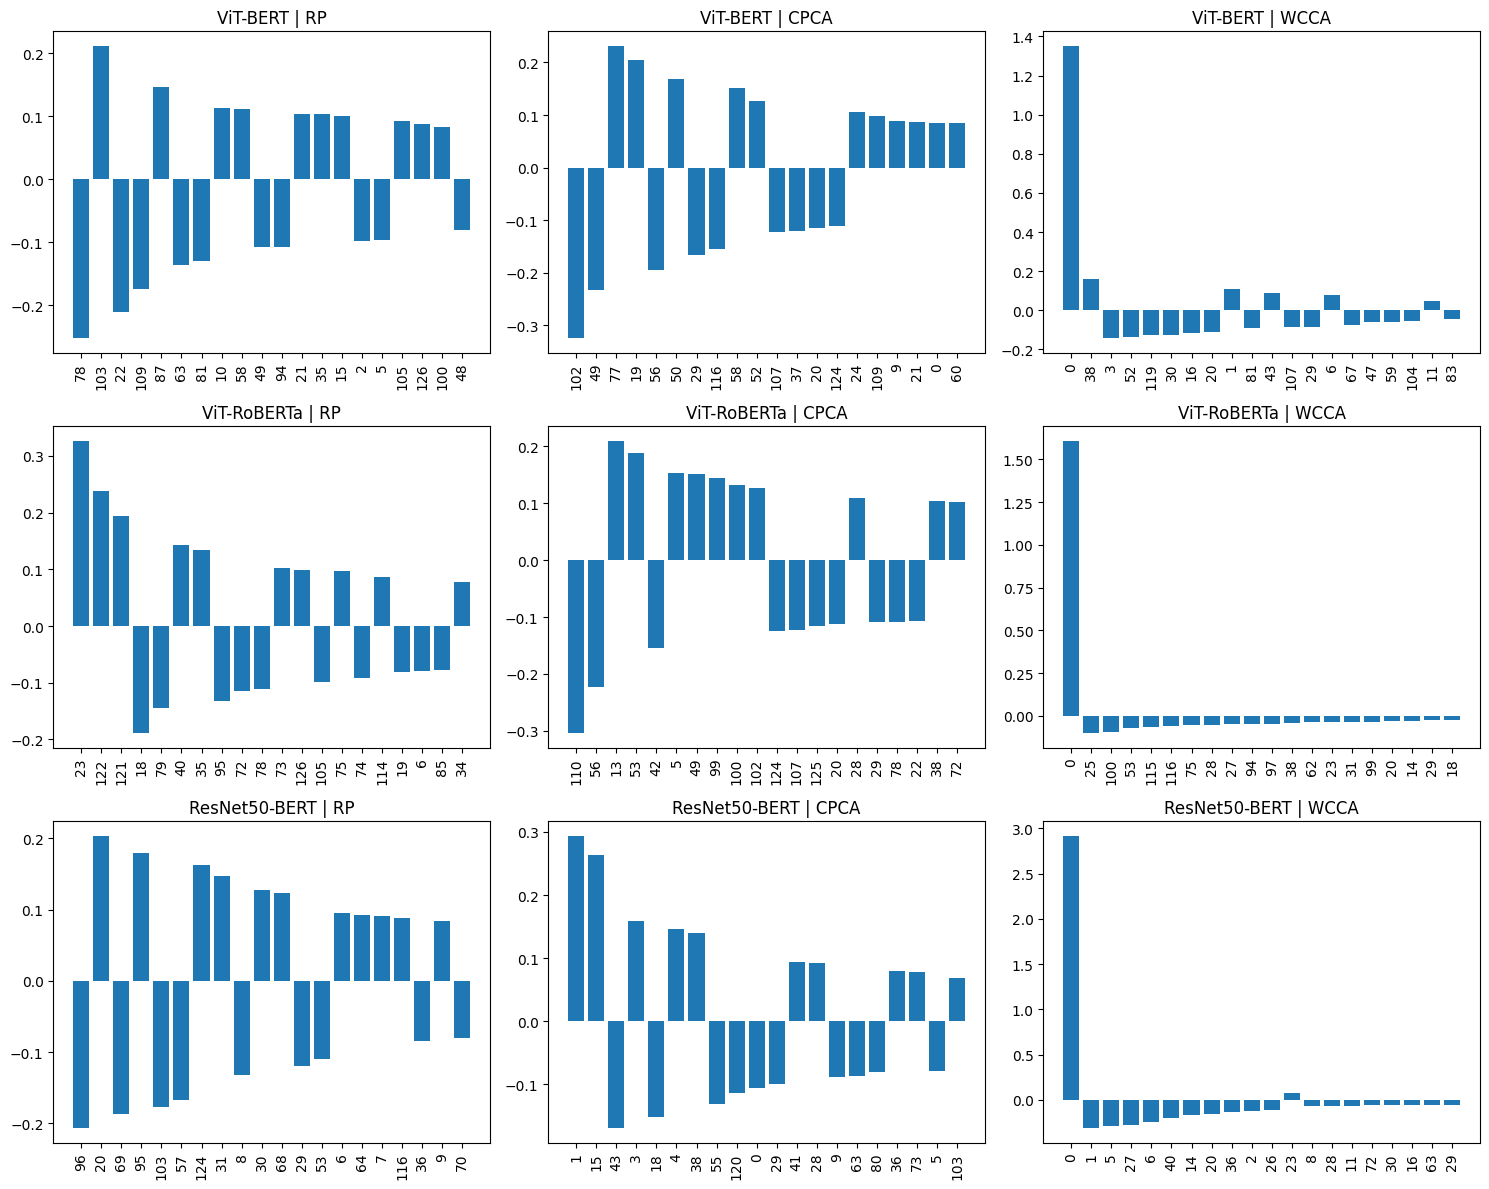

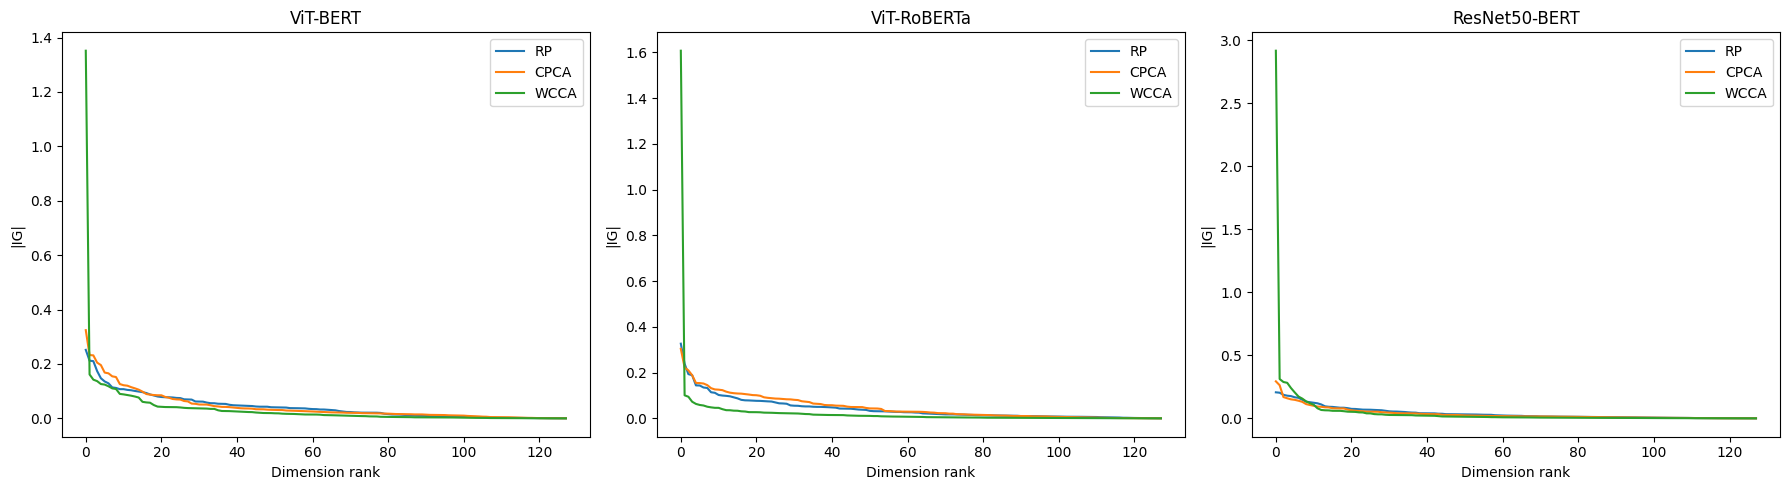

/tmp/ipykernel_580328/1137843752.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


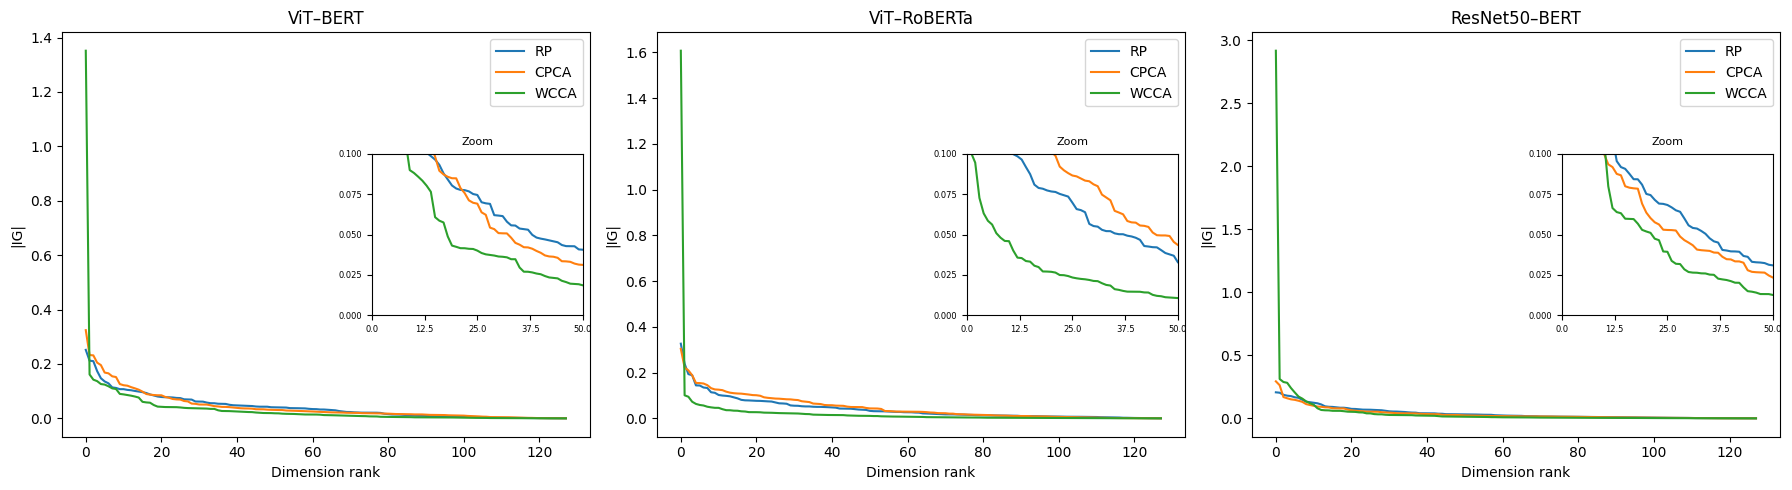

     Vision     Text Task Method          Mean       Std       Min       Max  \
0       ViT     BERT  i2t     RP  4.656613e-10  0.062655 -0.251720  0.211962   
1       ViT     BERT  i2t   CPCA -4.656613e-10  0.069515 -0.324199  0.231446   
2       ViT     BERT  i2t   WCCA  4.656613e-10  0.126653 -0.142216  1.351455   
3       ViT  RoBERTa  i2t     RP -2.328306e-10  0.064483 -0.188626  0.326486   
4       ViT  RoBERTa  i2t   CPCA -9.313226e-10  0.071406 -0.304118  0.209695   
5       ViT  RoBERTa  i2t   WCCA -2.328306e-09  0.143880 -0.100719  1.607495   
6  ResNet50     BERT  i2t     RP -1.164153e-09  0.061684 -0.206413  0.203276   
7  ResNet50     BERT  i2t   CPCA -2.328306e-10  0.059315 -0.168972  0.293530   
8  ResNet50     BERT  i2t   WCCA -9.313226e-10  0.265561 -0.311769  2.916347   

    L1 Norm  
0  5.412330  
1  5.526251  
2  4.539246  
3  5.259980  
4  6.084200  
5  3.330283  
6  5.039898  
7  4.458286  
8  6.634251  
t2i


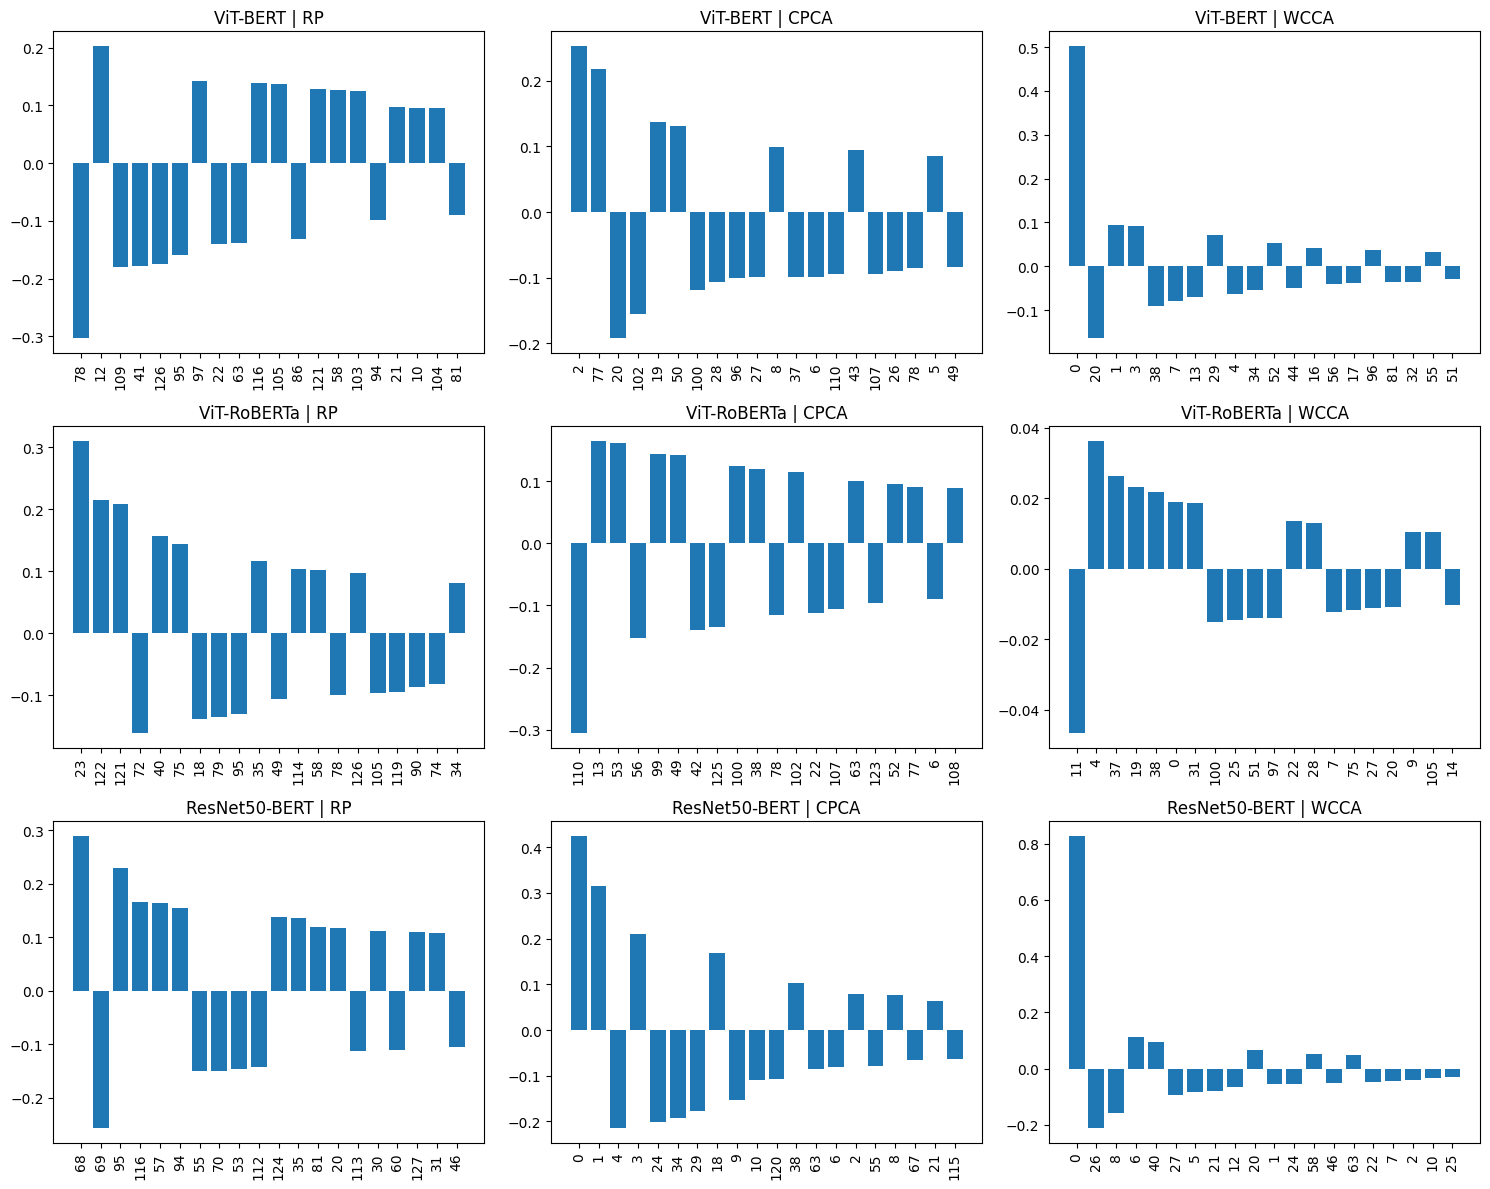

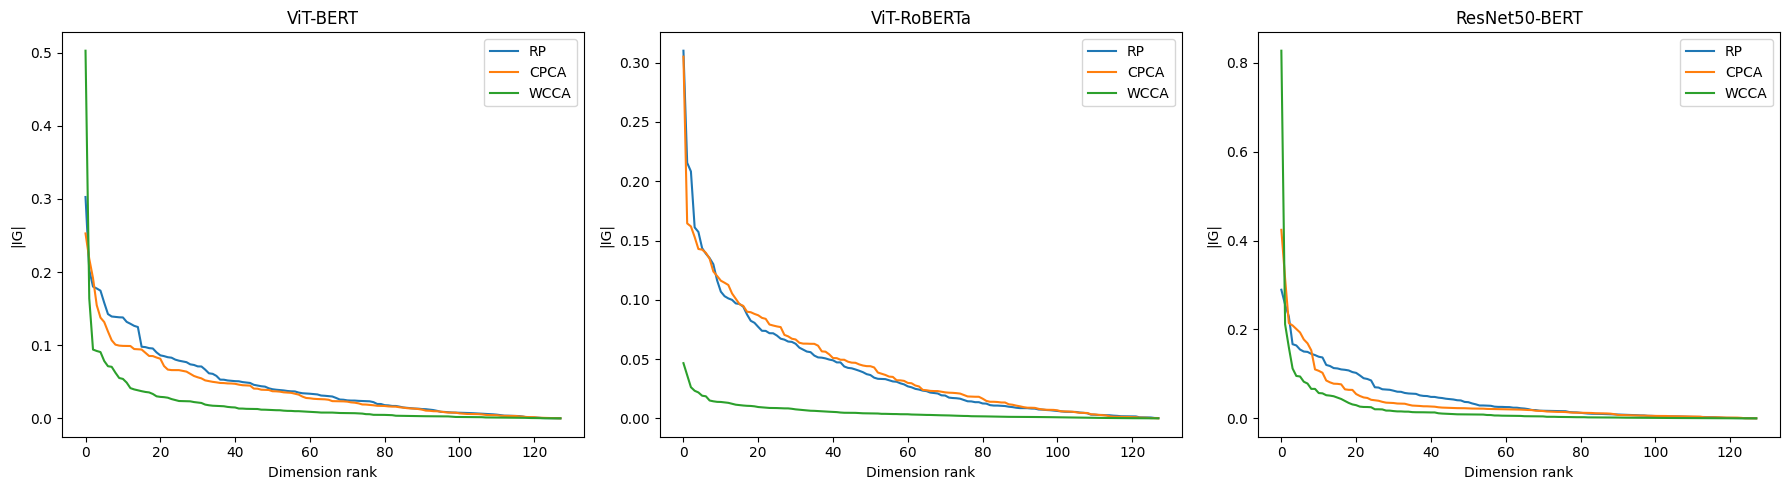

/tmp/ipykernel_580328/1137843752.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


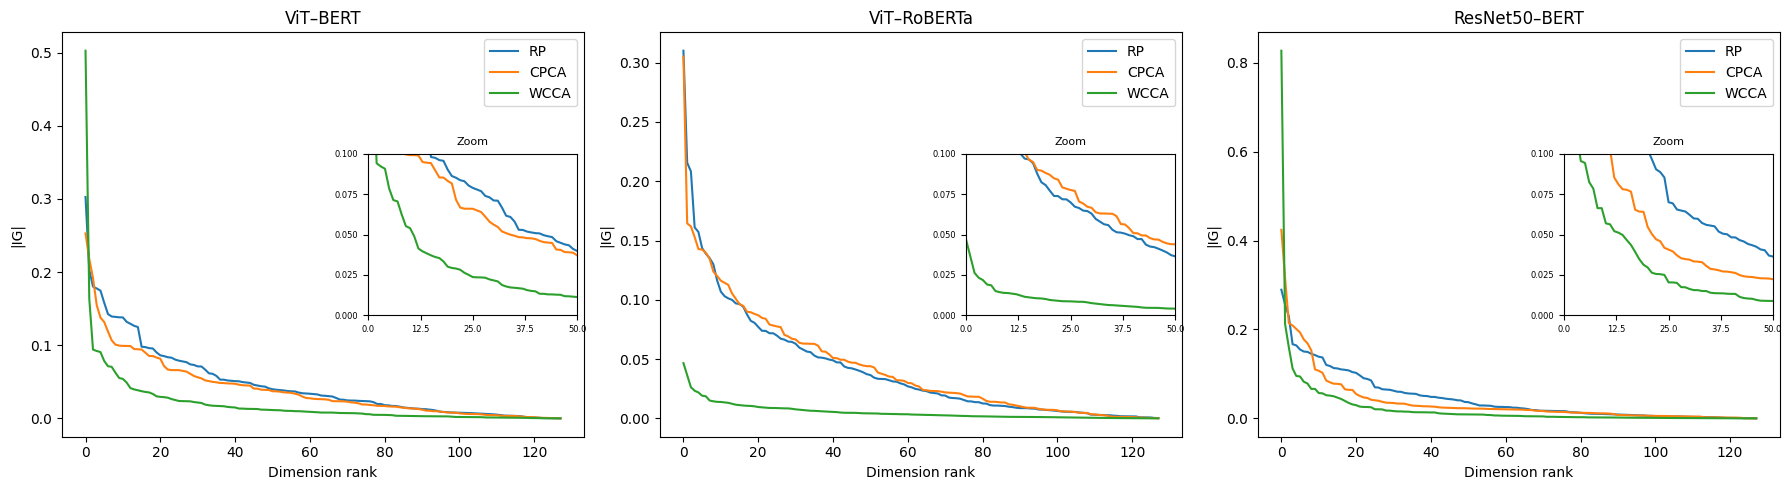

     Vision     Text Task Method          Mean       Std       Min       Max  \
0       ViT     BERT  t2i     RP  1.396984e-09  0.069329 -0.302729  0.203049   
1       ViT     BERT  t2i   CPCA -9.313226e-10  0.059533 -0.191797  0.252868   
2       ViT     BERT  t2i   WCCA  4.656613e-10  0.052886 -0.163864  0.502770   
3       ViT  RoBERTa  t2i     RP -4.656613e-10  0.064631 -0.161076  0.310067   
4       ViT  RoBERTa  t2i   CPCA -6.984919e-10  0.064207 -0.305056  0.164428   
5       ViT  RoBERTa  t2i   WCCA -2.328306e-10  0.008684 -0.046557  0.036307   
6  ResNet50     BERT  t2i     RP -9.313226e-10  0.070675 -0.256177  0.289495   
7  ResNet50     BERT  t2i   CPCA -9.313226e-10  0.071533 -0.214364  0.424381   
8  ResNet50     BERT  t2i   WCCA -1.513399e-09  0.080982 -0.211904  0.827591   

    L1 Norm  
0  6.005461  
1  5.151677  
2  2.565874  
3  5.323853  
4  5.568304  
5  0.675404  
6  5.728487  
7  4.752109  
8  2.944033  
m2t


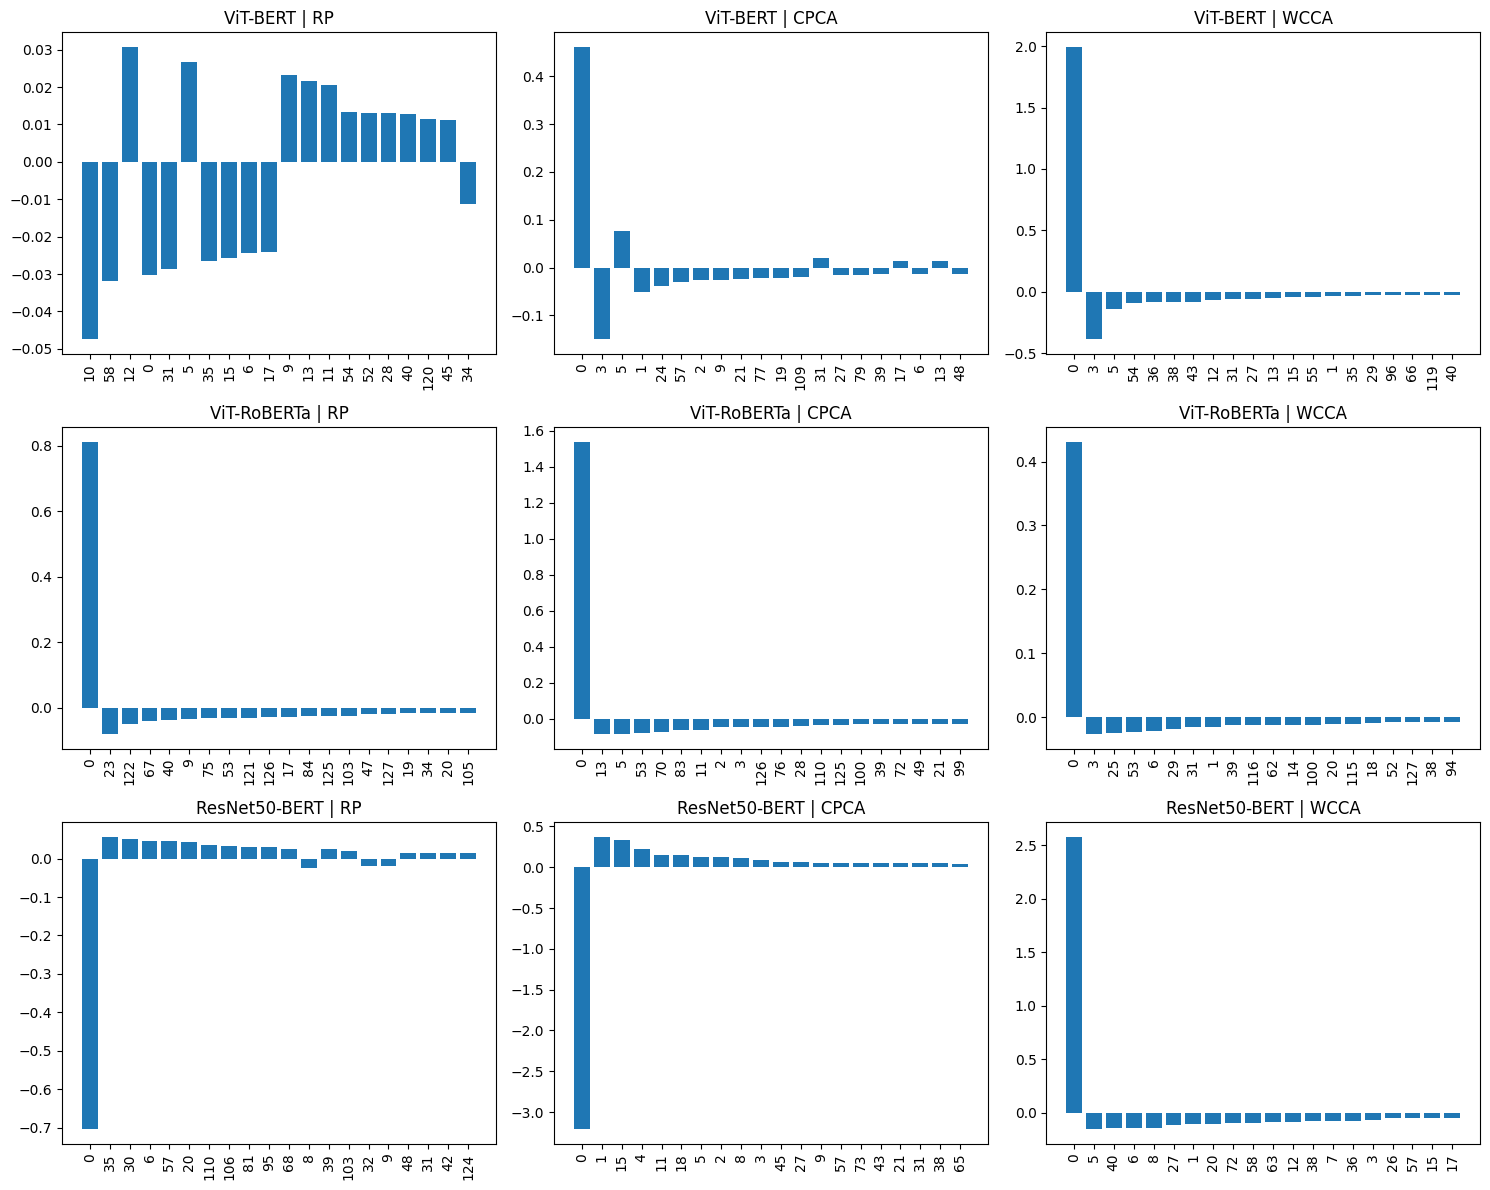

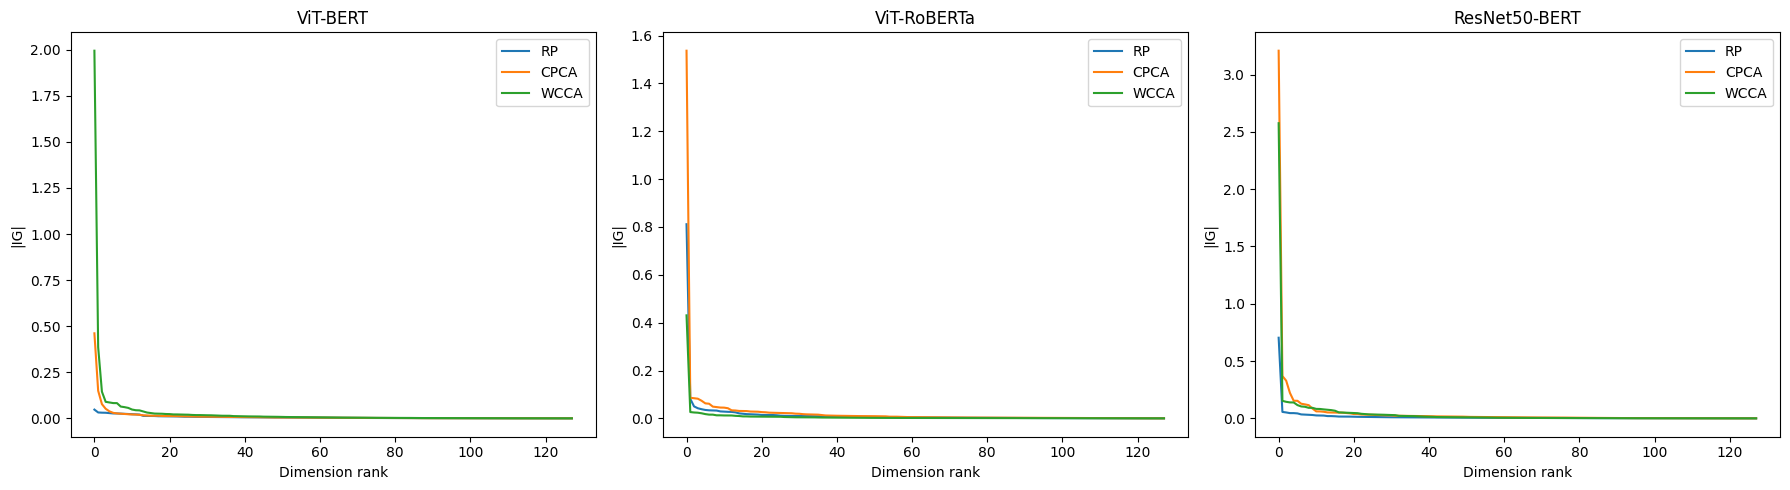

/tmp/ipykernel_580328/1137843752.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


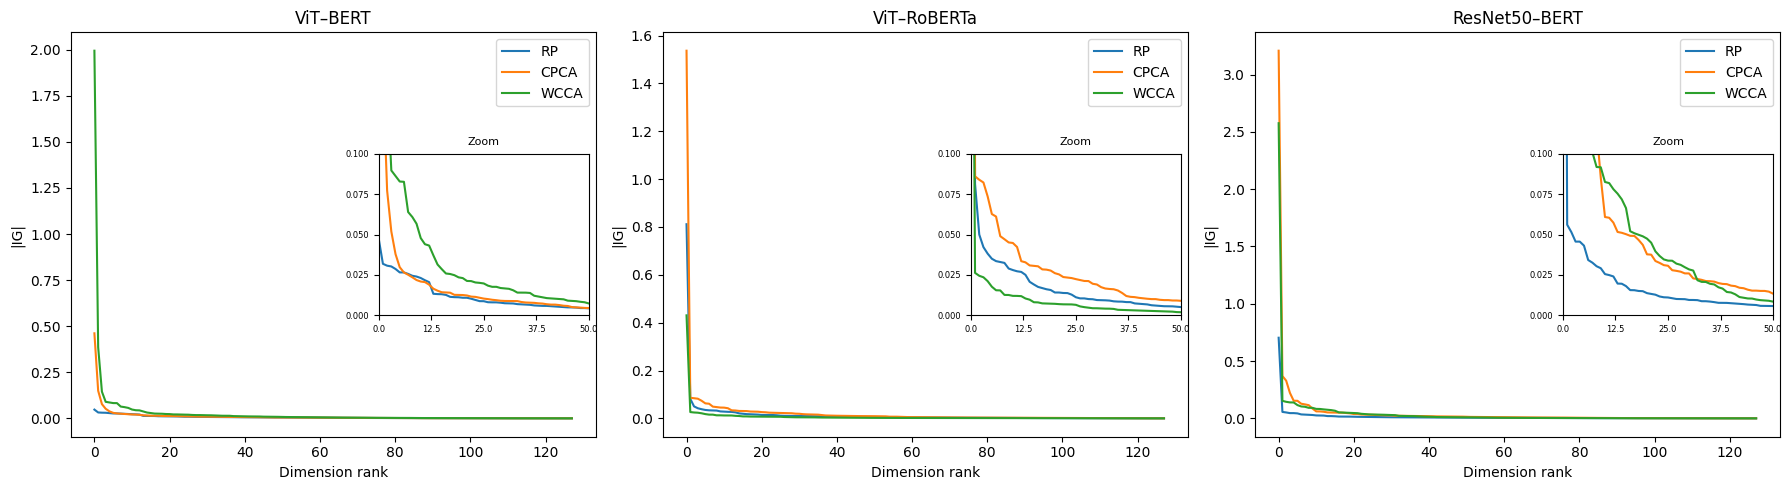

     Vision     Text Task Method          Mean       Std       Min       Max  \
0       ViT     BERT  m2t     RP  0.000000e+00  0.010299 -0.047391  0.030738   
1       ViT     BERT  m2t   CPCA  3.201421e-10  0.044527 -0.149721  0.461393   
2       ViT     BERT  m2t   WCCA  0.000000e+00  0.181341 -0.386440  1.994873   
3       ViT  RoBERTa  m2t     RP -9.313226e-10  0.073114 -0.081353  0.811563   
4       ViT  RoBERTa  m2t   CPCA  4.656613e-10  0.137614 -0.085981  1.537010   
5       ViT  RoBERTa  m2t   WCCA  6.984919e-10  0.038571 -0.026291  0.430616   
6  ResNet50     BERT  m2t     RP -1.396984e-09  0.063611 -0.703661  0.056074   
7  ResNet50     BERT  m2t   CPCA  0.000000e+00  0.289612 -3.208788  0.369658   
8  ResNet50     BERT  m2t   WCCA  9.313226e-10  0.231072 -0.152479  2.576003   

    L1 Norm  
0  0.776284  
1  1.420452  
2  3.992696  
3  1.822281  
4  3.149723  
5  0.871132  
6  1.700048  
7  6.437719  
8  5.155341  
m2i


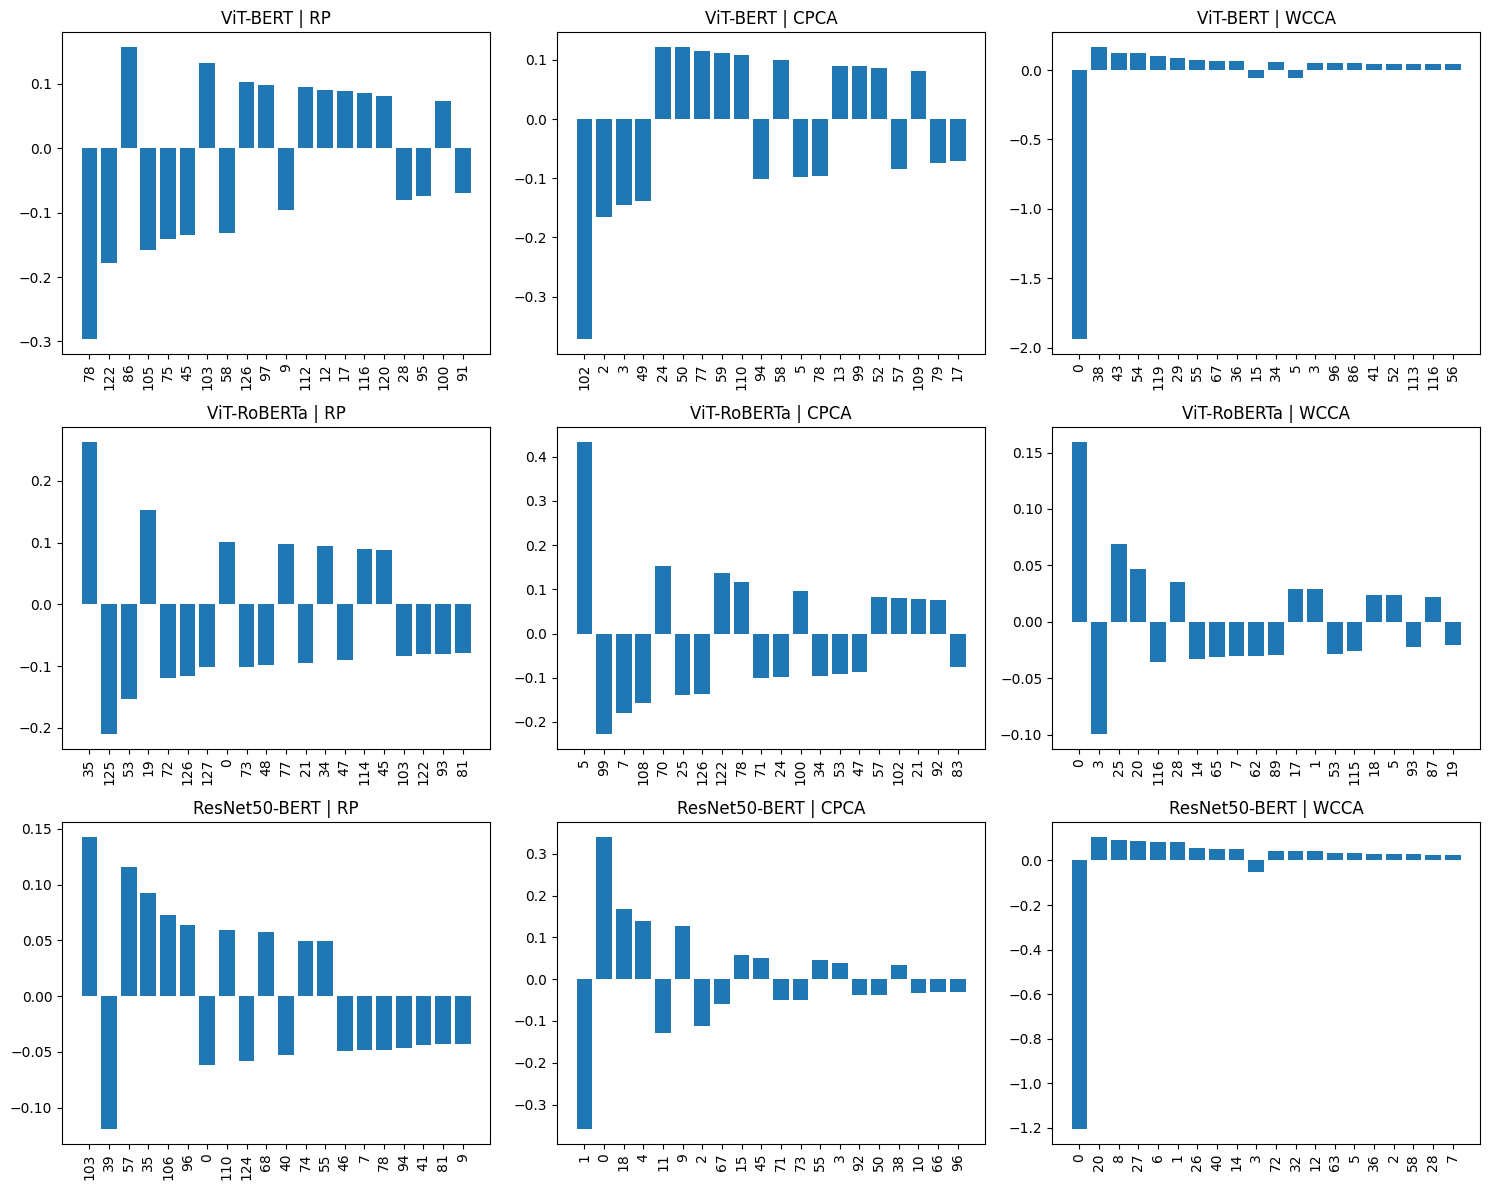

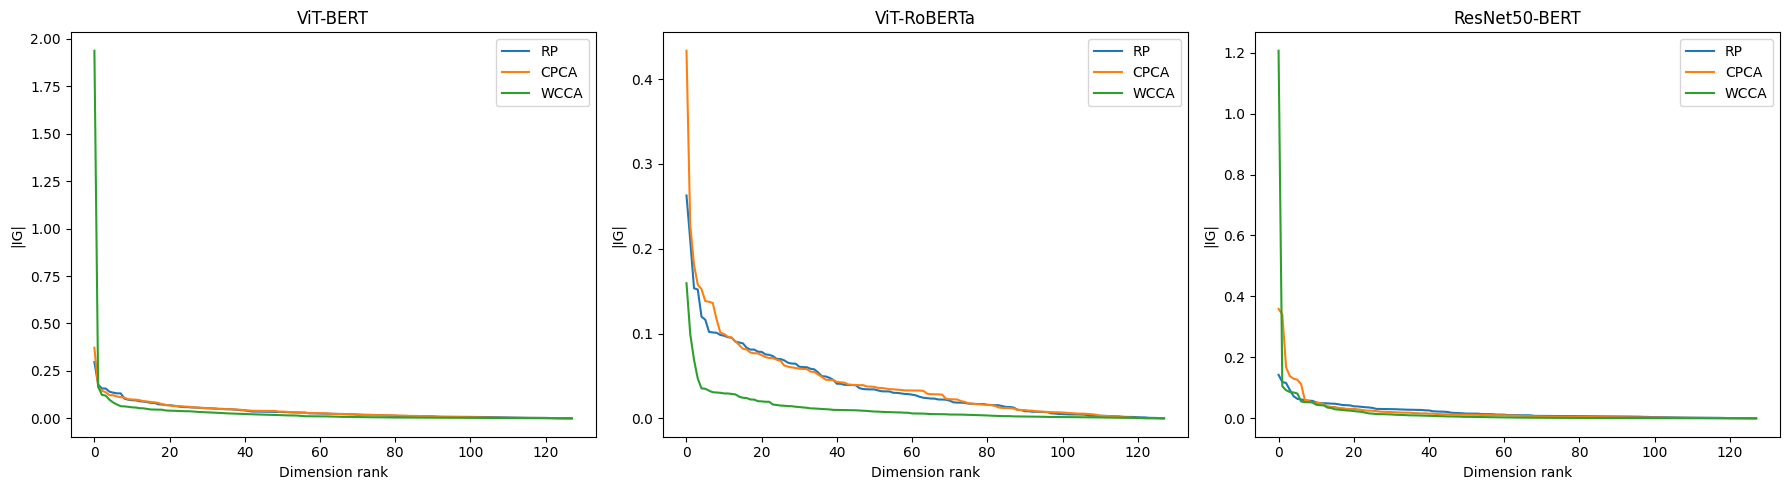

/tmp/ipykernel_580328/1137843752.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


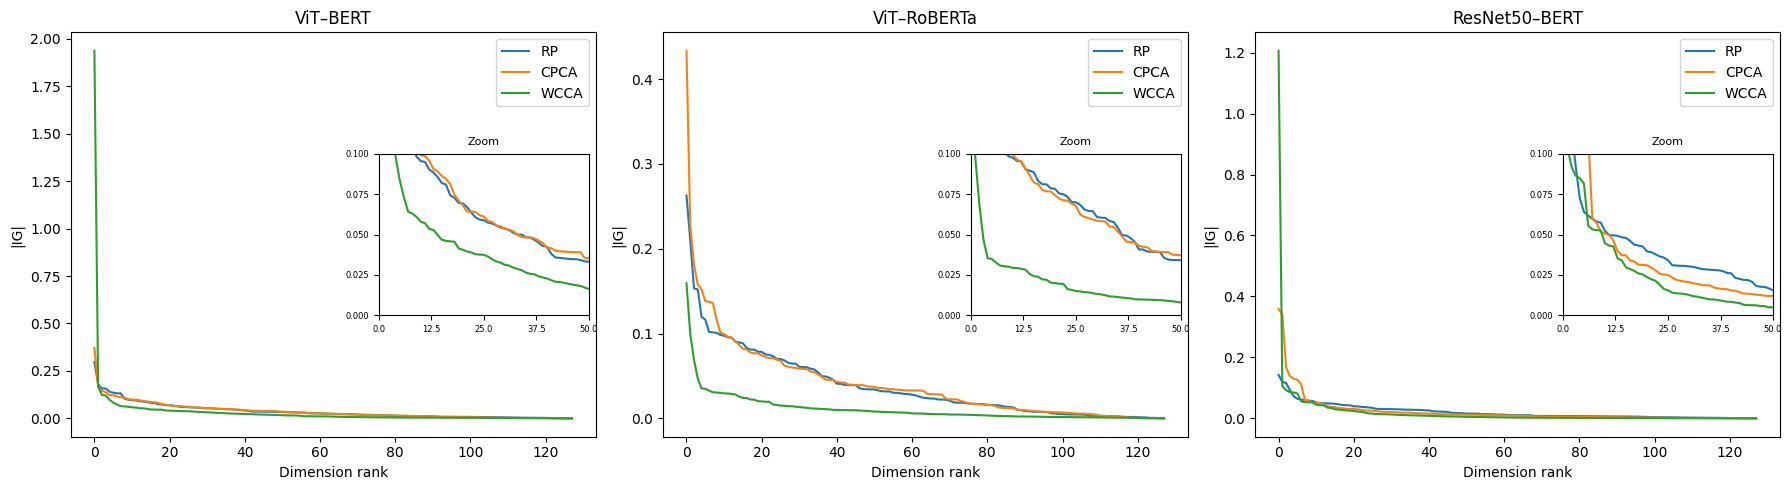

     Vision     Text Task Method          Mean       Std       Min       Max  \
0       ViT     BERT  m2i     RP  1.164153e-09  0.057677 -0.296397  0.157324   
1       ViT     BERT  m2i   CPCA -4.656613e-10  0.059806 -0.371943  0.121961   
2       ViT     BERT  m2i   WCCA  1.862645e-09  0.174524 -1.937617  0.166359   
3       ViT  RoBERTa  m2i     RP  4.656613e-10  0.057379 -0.209977  0.262721   
4       ViT  RoBERTa  m2i   CPCA -4.656613e-10  0.067970 -0.227675  0.433387   
5       ViT  RoBERTa  m2i   WCCA -8.731149e-11  0.021859 -0.099406  0.159330   
6  ResNet50     BERT  m2i     RP  1.688022e-09  0.032063 -0.119228  0.142786   
7  ResNet50     BERT  m2i   CPCA -1.746230e-09  0.054267 -0.359076  0.340608   
8  ResNet50     BERT  m2i   WCCA  2.793968e-09  0.109127 -1.206319  0.105165   

    L1 Norm  
0  4.824028  
1  4.850692  
2  4.503768  
3  4.931081  
4  5.349497  
5  1.430811  
6  2.647402  
7  2.850184  
8  2.656408  


In [355]:
for task in ["i2t", "t2i", "m2t", "m2i"]:
    print(task)
    plot_bar_grid(model_pairs, task)
    plot_sorted_curves(model_pairs, task)
    plot_sorted_curves_zoom(model_pairs, task)
    df_stats = compute_stats(model_pairs, task)
    print(df_stats)


# Quantus

In [356]:
QUANTUS_METRICS = [
    quantus.Complexity(),
    quantus.Sparseness(),
]


In [15]:
def run_quantus(wrapper, signal, attr, label, metrics):
    y_np = np.array([label], dtype=float)
    results = {}

    for m in metrics:
        try:
            out = m(
                model=wrapper,
                x_batch=signal,
                a_batch=attr,
                y_batch=y_np
            )
            results[m.__class__.__name__] = float(out[0])
        except Exception:
            results[m.__class__.__name__] = np.nan

    return results


In [16]:
def quantus_i2t_all(v, t, img_idx, cap_idx, steps=50):
    rows = []

    for method in ["RP", "CPCA", "WCCA"]:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_full"]

        # IG
        ig = ig_i2t(Xv_proj, Xt_proj, img_idx, cap_idx, steps=steps)
        ig_np = ig.numpy().reshape(1, -1)

        # Signal
        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj[cap_idx], dtype=torch.float32)
        signal = xv_i.numpy().reshape(1, -1)

        # Similarity label
        sim = cosine_sim(xv_i.unsqueeze(0), xt_j.unsqueeze(0)).item()

        # Wrapper
        wrapper = QuantusI2TWrapper(xt_j).eval()

        # Metrics
        metrics = [
            SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),
            quantus.Complexity(),
            quantus.Sparseness()
        ]


        qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
        qres.update({"Vision": v, "Text": t, "Method": method})

        rows.append(qres)

    return pd.DataFrame(rows)

def quantus_t2i_all(v, t, cap_idx, img_idx, steps=50):
    rows = []

    for method in ["RP", "CPCA", "WCCA"]:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_full"]

        ig = ig_t2i(Xv_proj, Xt_proj, img_idx, cap_idx, steps=steps)
        ig_np = ig.numpy().reshape(1, -1)

        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj[cap_idx], dtype=torch.float32)
        signal = xt_j.numpy().reshape(1, -1)

        sim = cosine_sim(xv_i.unsqueeze(0), xt_j.unsqueeze(0)).item()
        wrapper = QuantusT2IWrapper(xv_i).eval()

        metrics = [
            SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),
            quantus.Complexity(),
            quantus.Sparseness()
        ]


        qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
        qres.update({"Vision": v, "Text": t, "Method": method})

        rows.append(qres)

    return pd.DataFrame(rows)

def quantus_m2t_all(v, t, img_idx, cap_idx, fusion="add", steps=50):
    rows = []

    for method in ["RP", "CPCA", "WCCA"]:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_grouped"]

        ig = ig_m2t(Xv_proj, Xt_proj, img_idx, cap_idx, fusion=fusion, steps=steps)
        ig_np = ig.numpy().reshape(1, -1)

        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj_full[cap_idx], dtype=torch.float32)
        F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[img_idx], Xt_proj[img_idx]), dtype=torch.float32)

        signal = F_i.numpy().reshape(1, -1)
        sim = cosine_sim(F_i.unsqueeze(0), xt_j.unsqueeze(0)).item()

        wrapper = QuantusI2TWrapper(xt_j).eval()

        metrics = [
            SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),
            quantus.Complexity(),
            quantus.Sparseness()
        ]


        qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
        qres.update({"Vision": v, "Text": t, "Method": method, "Fusion": fusion})

        rows.append(qres)

    return pd.DataFrame(rows)

def quantus_m2i_all(v, t, img_idx, cap_idx, fusion="add", steps=50):
    rows = []

    for method in ["RP", "CPCA", "WCCA"]:
        cfg = proj_all[(v, t, method)]
        Xv_proj = cfg["Xv"]
        Xt_proj = cfg["Xt_grouped"]

        ig = ig_m2i(Xv_proj, Xt_proj, img_idx, cap_idx, fusion=fusion, steps=steps)
        ig_np = ig.numpy().reshape(1, -1)

        xv_i = torch.tensor(Xv_proj[img_idx], dtype=torch.float32)
        xt_j = torch.tensor(Xt_proj_full[cap_idx], dtype=torch.float32)
        F_i = torch.tensor(FUSION_FUNCS[fusion](Xv_proj[img_idx], Xt_proj[img_idx]), dtype=torch.float32)

        signal = F_i.numpy().reshape(1, -1)
        sim = cosine_sim(F_i.unsqueeze(0), xv_i.unsqueeze(0)).item()

        wrapper = QuantusT2IWrapper(xv_i).eval()

        metrics = [
            SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),
            quantus.Complexity(),
            quantus.Sparseness()
        ]


        qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
        qres.update({"Vision": v, "Text": t, "Method": method, "Fusion": fusion})

        rows.append(qres)

    return pd.DataFrame(rows)


In [17]:

def run_quantus_single(v, t, task, fusion=None):
    
    img_idx, cap_idx = get_top1(v, t, task, fusion)

    if task == "i2t":
        return quantus_i2t_all(v, t, img_idx, cap_idx)

    if task == "t2i":
        return quantus_t2i_all(v, t, cap_idx, img_idx)

    if task == "m2t":
        return quantus_m2t_all(v, t, img_idx, cap_idx, fusion=fusion)

    if task == "m2i":
        return quantus_m2i_all(v, t, img_idx, cap_idx, fusion=fusion)

    raise ValueError("Unknown task")

def run_all_quantus(model_pairs, fusions=["add", "gated", "mul"]):
    all_rows = []

    for v, t in model_pairs:
        for task, meta in TASKS.items():

            if meta["needs_fusion"]:
                # multimodal tasks → loop over all fusions
                for fusion in fusions:
                    df = run_quantus_single(v, t, task, fusion)
                    df["Fusion"] = fusion
                    df["Task"] = task
                    all_rows.append(df)

            else:
                # unimodal tasks → no fusion
                df = run_quantus_single(v, t, task)
                df["Fusion"] = None
                df["Task"] = task
                all_rows.append(df)

    return pd.concat(all_rows, ignore_index=True)


In [25]:
quantus_results = run_all_quantus(model_pairs)
quantus_results

,SimilarityDropFaithfulnessMetric,Complexity,Sparseness,Vision,Text,Method,Fusion,Task
0,0.022403,4.331828,0.546652,ViT,BERT,RP,None,i2t
1,-0.004755,4.267758,0.574125,ViT,BERT,CPCA,None,i2t
2,0.133133,3.511703,0.730352,ViT,BERT,WCCA,None,i2t
3,-0.023000,4.349868,0.541466,ViT,BERT,RP,None,t2i
4,-0.050841,4.361242,0.533621,ViT,BERT,CPCA,None,t2i
...,...,...,...,...,...,...,...,...
67,-0.456677,3.796144,0.702159,ResNet50,BERT,CPCA,gated,m2i
68,0.563293,2.774867,0.842145,ResNet50,BERT,WCCA,gated,m2i
69,-0.013814,3.919481,0.700924,ResNet50,BERT,RP,mul,m2i
70,-0.512101,2.653971,0.876779,ResNet50,BERT,CPCA,mul,m2i


In [44]:
# Desired column order
first_cols = ["Vision", "Text", "Method", "Fusion", "Task"]

# All other columns (metrics)
other_cols = [c for c in quantus_results.columns if c not in first_cols]

# Reorder columns
quantus_results = quantus_results[first_cols + other_cols]

# Sort by task (and optionally by model)
quantus_results = quantus_results.sort_values(
    by=["Task", "Vision", "Text", "Method", "Fusion"],
    ignore_index=True
)

quantus_results


,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,ResNet50,BERT,CPCA,None,i2t,-0.002039,4.181225,0.611241
1,ResNet50,BERT,RP,None,i2t,0.123698,4.254809,0.588296
2,ResNet50,BERT,WCCA,None,i2t,0.294466,2.806885,0.837837
3,ViT,BERT,CPCA,None,i2t,-0.004755,4.267758,0.574125
4,ViT,BERT,RP,None,i2t,0.022403,4.331828,0.546652
...,...,...,...,...,...,...,...,...
67,ViT,BERT,RP,None,t2i,-0.023000,4.349868,0.541466
68,ViT,BERT,WCCA,None,t2i,0.147480,3.816323,0.686855
69,ViT,RoBERTa,CPCA,None,t2i,0.029092,4.341500,0.544638
70,ViT,RoBERTa,RP,None,t2i,0.056226,4.289830,0.569198


In [46]:
quantus_by_task = {
    task: df.sort_values(
        by=["Vision", "Text", "Method", "Fusion"],
        ignore_index=True
    )
    for task, df in quantus_results.groupby("Task")
}


In [28]:
quantus_by_task["i2t"]



,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,ResNet50,BERT,CPCA,None,i2t,-0.002039,4.181225,0.611241
1,ResNet50,BERT,RP,None,i2t,0.123698,4.254809,0.588296
2,ResNet50,BERT,WCCA,None,i2t,0.294466,2.806885,0.837837
3,ViT,BERT,CPCA,None,i2t,-0.004755,4.267758,0.574125
4,ViT,BERT,RP,None,i2t,0.022403,4.331828,0.546652
5,ViT,BERT,WCCA,None,i2t,0.133133,3.511703,0.730352
6,ViT,RoBERTa,CPCA,None,i2t,0.027570,4.302976,0.564375
7,ViT,RoBERTa,RP,None,i2t,0.060776,4.304782,0.559365
8,ViT,RoBERTa,WCCA,None,i2t,0.172860,2.844273,0.793968


In [39]:
quantus_by_task["t2i"]


,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,ResNet50,BERT,CPCA,None,t2i,-0.011315,4.075737,0.631970
1,ResNet50,BERT,RP,None,t2i,0.145567,4.242393,0.593132
2,ResNet50,BERT,WCCA,None,t2i,0.476642,3.369706,0.781486
3,ViT,BERT,CPCA,None,t2i,-0.050841,4.361242,0.533621
4,ViT,BERT,RP,None,t2i,-0.023000,4.349868,0.541466
5,ViT,BERT,WCCA,None,t2i,0.147480,3.816323,0.686855
6,ViT,RoBERTa,CPCA,None,t2i,0.029092,4.341500,0.544638
7,ViT,RoBERTa,RP,None,t2i,0.056226,4.289830,0.569198
8,ViT,RoBERTa,WCCA,None,t2i,0.189944,4.244722,0.582859


In [48]:
quantus_by_task["m2i"]


,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,ResNet50,BERT,CPCA,add,m2i,-0.456677,3.796144,0.702159
1,ResNet50,BERT,CPCA,gated,m2i,-0.456677,3.796144,0.702159
2,ResNet50,BERT,CPCA,mul,m2i,-0.512101,2.653971,0.876779
3,ResNet50,BERT,RP,add,m2i,0.019213,4.309996,0.558502
4,ResNet50,BERT,RP,gated,m2i,0.019213,4.309996,0.558502
5,ResNet50,BERT,RP,mul,m2i,-0.013814,3.919481,0.700924
6,ResNet50,BERT,WCCA,add,m2i,0.563293,2.774867,0.842145
7,ResNet50,BERT,WCCA,gated,m2i,0.563293,2.774867,0.842145
8,ResNet50,BERT,WCCA,mul,m2i,0.600201,3.346493,0.821163
9,ViT,BERT,CPCA,add,m2i,-0.014331,4.307903,0.553094


In [32]:
quantus_by_task["m2i"]

,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,ResNet50,BERT,CPCA,add,m2i,-0.456677,3.796144,0.702159
1,ResNet50,BERT,CPCA,gated,m2i,-0.456677,3.796144,0.702159
2,ResNet50,BERT,CPCA,mul,m2i,-0.512101,2.653971,0.876779
3,ResNet50,BERT,RP,add,m2i,0.019213,4.309996,0.558502
4,ResNet50,BERT,RP,gated,m2i,0.019213,4.309996,0.558502
5,ResNet50,BERT,RP,mul,m2i,-0.013814,3.919481,0.700924
6,ResNet50,BERT,WCCA,add,m2i,0.563293,2.774867,0.842145
7,ResNet50,BERT,WCCA,gated,m2i,0.563293,2.774867,0.842145
8,ResNet50,BERT,WCCA,mul,m2i,0.600201,3.346493,0.821163
9,ViT,BERT,CPCA,add,m2i,-0.014331,4.307903,0.553094


In [33]:
def run_sota_quantus_full(sota_models, steps=50, fusions=("add", "gated", "mul")):
    rows = []

    for name, model in sota_models.items():
        print(f"=== SOTA Quantus: {name} ===")

        Xv = model["vision"]          # (8000, d)
        Xt_full = model["text_full"]  # (40000, d)
        Xt_grouped = model["text_grouped"]  # (8000, d)

        # -------------------------
        # I2T
        # -------------------------
        top50 = load_top50(DATASET, name, name, "sota", "i2t")
        if top50 is not None:
            entry = top50[0]
            img_idx = entry["query_index"]
            cap_idx = entry["top50_indices"][0]

            ig = ig_i2t(Xv, Xt_full, img_idx, cap_idx, steps=steps)
            ig_np = ig.numpy().reshape(1, -1)

            xv_i = torch.tensor(Xv[img_idx], dtype=torch.float32)
            xt_j = torch.tensor(Xt_full[cap_idx], dtype=torch.float32)
            signal = xv_i.numpy().reshape(1, -1)
            sim = cosine_sim(xv_i, xt_j).item()

            wrapper = QuantusI2TWrapper(xt_j).eval()
            metrics = [     SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),     quantus.Complexity(),     quantus.Sparseness() ]

            qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
            qres.update({"Vision": name, "Text": name, "Method": "sota",
                         "Fusion": None, "Task": "i2t"})
            rows.append(qres)

        # -------------------------
        # T2I
        # -------------------------
        top50 = load_top50(DATASET, name, name, "sota", "t2i")
        if top50 is not None:
            entry = top50[0]
            cap_idx = entry["query_index"]
            img_idx = entry["top50_indices"][0]

            ig = ig_t2i(Xv, Xt_full, img_idx, cap_idx, steps=steps)
            ig_np = ig.numpy().reshape(1, -1)

            xv_i = torch.tensor(Xv[img_idx], dtype=torch.float32)
            xt_j = torch.tensor(Xt_full[cap_idx], dtype=torch.float32)
            signal = xt_j.numpy().reshape(1, -1)
            sim = cosine_sim(xv_i, xt_j).item()

            wrapper = QuantusT2IWrapper(xv_i).eval()
            metrics = [     SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),     quantus.Complexity(),     quantus.Sparseness() ]

            qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
            qres.update({"Vision": name, "Text": name, "Method": "sota",
                         "Fusion": None, "Task": "t2i"})
            rows.append(qres)

        # -------------------------
        # M2T (add / gated / mul)
        # -------------------------
        for fusion in fusions:
            task = f"m2t_{fusion}"
            top50 = load_top50(DATASET, name, name, "sota", task)
            if top50 is None:
                continue

            entry = top50[0]
            img_idx = entry["query_index"]
            cap_idx = entry["top50_indices"][0]

            # fused query in SOTA space
            F_i = torch.tensor(FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx]),
                               dtype=torch.float32)
            xt_j = torch.tensor(Xt_full[cap_idx], dtype=torch.float32)

            ig = ig_on_embedding(F_i, xt_j, steps=steps)
            ig_np = ig.numpy().reshape(1, -1)

            signal = F_i.numpy().reshape(1, -1)
            sim = cosine_sim(F_i, xt_j).item()

            wrapper = QuantusI2TWrapper(xt_j).eval()
            metrics = [     SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),     quantus.Complexity(),     quantus.Sparseness() ]

            qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
            qres.update({"Vision": name, "Text": name, "Method": "sota",
                         "Fusion": fusion, "Task": "m2t"})
            rows.append(qres)

        # -------------------------
        # M2I (add / gated / mul)
        # -------------------------
        for fusion in fusions:
            task = f"m2i_{fusion}"
            top50 = load_top50(DATASET, name, name, "sota", task)
            if top50 is None:
                continue

            entry = top50[0]
            img_idx = entry["query_index"]
            img_j = entry["top50_indices"][0]

            F_i = torch.tensor(FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx]),
                               dtype=torch.float32)
            xv_j = torch.tensor(Xv[img_j], dtype=torch.float32)

            ig = ig_on_embedding(F_i, xv_j, steps=steps)
            ig_np = ig.numpy().reshape(1, -1)

            signal = F_i.numpy().reshape(1, -1)
            sim = cosine_sim(F_i, xv_j).item()

            wrapper = QuantusT2IWrapper(xv_j).eval()
            metrics = [     SimilarityDropFaithfulnessMetric(xv_i.numpy(), xt_j.numpy(), ig, k=20),     quantus.Complexity(),     quantus.Sparseness() ]

            qres = run_quantus(wrapper, signal, ig_np, sim, metrics)
            qres.update({"Vision": name, "Text": name, "Method": "sota",
                         "Fusion": fusion, "Task": "m2i"})
            rows.append(qres)

    return pd.DataFrame(rows)


In [4]:
def group_captions(Xt_raw, k=5):
    N = Xt_raw.shape[0] // k
    return Xt_raw.reshape(N, k, -1).mean(axis=1)

def load_sota_embeddings(model_name):
    if model_name == "CLIP ViT‑B/32" or model_name == "CLIP":
        vision_embs = np.load(vision_emb_path("Flickr8k", "CLIP"))
        text_embs   = np.load(text_emb_path("Flickr8k", "CLIP"))
    elif model_name == "OpenCLIP ViT‑L/14" or model_name == "OpenCLIP":
        vision_embs = np.load(vision_emb_path("Flickr8k", "OpenCLIPL14"))
        text_embs   = np.load(text_emb_path("Flickr8k", "OpenCLIPL14"))
    else:
        raise ValueError(f"Unknown SOTA model: {model_name}")
    
    text_grouped = group_captions(text_embs, k=5)
    
    return vision_embs, text_embs, text_grouped

SOTA_MODELS = {}
for name in ["CLIP", "OpenCLIP"]:
    v_emb, t_emb, t_emb_grouped = load_sota_embeddings(name)
    SOTA_MODELS[name] = {
        "vision": v_emb,              # (8000, d)
        "text_full": t_emb,           # (40000, d)
        "text_grouped": t_emb_grouped # (8000, d)
    }

print("Loaded SOTA embeddings:", list(SOTA_MODELS.keys()))

Loaded SOTA embeddings: ['CLIP', 'OpenCLIP']


In [34]:
quantus_sota_results = run_sota_quantus_full(SOTA_MODELS)


# Desired column order
first_cols = ["Vision", "Text", "Method", "Fusion", "Task"]

# All other columns (metrics)
other_cols = [c for c in quantus_sota_results.columns if c not in first_cols]

# Reorder columns
quantus_sota_results = quantus_sota_results[first_cols + other_cols]

# Sort by task (and optionally by model)
quantus_sota_results = quantus_sota_results.sort_values(
    by=["Task", "Vision", "Text", "Method", "Fusion"],
    ignore_index=True
)

quantus_sota_results


=== SOTA Quantus: CLIP ===
=== SOTA Quantus: OpenCLIP ===


,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,CLIP,CLIP,sota,NaN,i2t,0.062197,5.066928,0.685138
1,OpenCLIP,OpenCLIP,sota,NaN,i2t,0.005156,5.232492,0.711351
2,CLIP,CLIP,sota,add,m2i,0.135992,3.977799,0.813449
3,CLIP,CLIP,sota,gated,m2i,0.135992,3.977799,0.813449
4,CLIP,CLIP,sota,mul,m2i,0.139737,3.524121,0.891870
5,OpenCLIP,OpenCLIP,sota,add,m2i,0.019239,4.480283,0.793714
6,OpenCLIP,OpenCLIP,sota,gated,m2i,0.019239,4.480283,0.793714
7,OpenCLIP,OpenCLIP,sota,mul,m2i,0.053653,2.918218,0.924174
8,CLIP,CLIP,sota,add,m2t,0.092060,4.147806,0.786728
9,CLIP,CLIP,sota,gated,m2t,0.092060,4.147806,0.786728


In [40]:
quantus_by_task = {
    task: df.sort_values(
        by=["Vision", "Text", "Method", "Fusion"],
        ignore_index=True
    )
    for task, df in quantus_sota_results.groupby("Task")
}


In [43]:
quantus_by_task["m2i"]


,Vision,Text,Method,Fusion,Task,SimilarityDropFaithfulnessMetric,Complexity,Sparseness
0,CLIP,CLIP,sota,add,m2i,0.135992,3.977799,0.813449
1,CLIP,CLIP,sota,gated,m2i,0.135992,3.977799,0.813449
2,CLIP,CLIP,sota,mul,m2i,0.139737,3.524121,0.891870
3,OpenCLIP,OpenCLIP,sota,add,m2i,0.019239,4.480283,0.793714
4,OpenCLIP,OpenCLIP,sota,gated,m2i,0.019239,4.480283,0.793714
5,OpenCLIP,OpenCLIP,sota,mul,m2i,0.053653,2.918218,0.924174


In [399]:
def compute_stats_all(model_pairs, sota_models, task, fusion="add", steps=50):
    rows = []

    # ---------------------------------------------------------
    # ALIGNED MODELS (RP / CPCA / WCCA)
    # ---------------------------------------------------------
    for v, t in model_pairs:
        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)

        for method in ["RP", "CPCA", "WCCA"]:
            ig = compute_ig_for_task(v, t, method, task, img_idx, cap_idx, fusion, steps).numpy()

            rows.append({
                "Vision": v,
                "Text": t,
                "Task": task,
                "Fusion": fusion if task.startswith("m2") else None,
                "Method": method,
                "Mean": ig.mean(),
                "Std": ig.std(),
                "Min": ig.min(),
                "Max": ig.max(),
                "L1 Norm": np.abs(ig).sum(),
            })

    # ---------------------------------------------------------
    # SOTA MODELS (ONE METHOD ONLY)
    # ---------------------------------------------------------
    for name, model in sota_models.items():
        # SOTA uses its own top-1 pair
        if task in ["i2t", "t2i"]:
            top50 = load_top50(DATASET, name, name, "sota", task)
        else:
            top50 = load_top50(DATASET, name, name, "sota", f"{task}_{fusion}")

        if top50 is None:
            continue

        entry = top50[0]
        img_idx = entry["query_index"]
        cap_idx = entry["top50_indices"][0]

        # Compute IG for SOTA
        ig = compute_ig_for_task(name, name, "sota", task, img_idx, cap_idx, fusion, steps).numpy()

        rows.append({
            "Vision": name,
            "Text": name,
            "Task": task,
            "Fusion": fusion if task.startswith("m2") else None,
            "Method": "sota",
            "Mean": ig.mean(),
            "Std": ig.std(),
            "Min": ig.min(),
            "Max": ig.max(),
            "L1 Norm": np.abs(ig).sum(),
        })

    return pd.DataFrame(rows)


In [401]:
def plot_bar_grid_aligned_vs_sota(model_pairs, sota_models, task, fusion="add", topk=20):
    """
    Left 3 columns: aligned models (RP, CPCA, WCCA)
    Right N columns: SOTA models (single method = 'sota')
    """

    aligned_cols = 3
    sota_cols = len(sota_models)
    total_cols = aligned_cols + sota_cols

    fig, axes = plt.subplots(len(model_pairs), total_cols, figsize=(5 * total_cols, 4 * len(model_pairs)))

    # ---------------------------------------------------------
    # LEFT SIDE: ALIGNED MODELS (RP / CPCA / WCCA)
    # ---------------------------------------------------------
    for i, (v, t) in enumerate(model_pairs):
        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)
        ig_dict = compute_all_proj_ig(v, t, task, img_idx, cap_idx, fusion)

        for j, method in enumerate(["RP", "CPCA", "WCCA"]):
            ax = axes[i, j]
            ig = ig_dict[method]
            idx = np.argsort(-np.abs(ig))[:topk]

            ax.bar(range(topk), ig[idx])
            ax.set_xticks(range(topk))
            ax.set_xticklabels(idx, rotation=90)
            ax.set_title(f"{v}-{t} | {method}")

    # ---------------------------------------------------------
    # RIGHT SIDE: SOTA MODELS (ONE METHOD ONLY)
    # ---------------------------------------------------------
    for col, (name, model) in enumerate(sota_models.items()):
        Xv = model["vision"]
        Xt_full = model["text_full"]
        Xt_grouped = model["text_grouped"]

        for i, (v, t) in enumerate(model_pairs):
            ax = axes[i, aligned_cols + col]

            # Load top-1 for SOTA
            if task in ["i2t", "t2i"]:
                top50 = load_top50(DATASET, name, name, "sota", task)
            else:
                top50 = load_top50(DATASET, name, name, "sota", f"{task}_{fusion}")

            if top50 is None:
                ax.set_title(f"{name} | No data")
                ax.axis("off")
                continue

            entry = top50[0]
            img_idx = entry["query_index"]
            cap_idx = entry["top50_indices"][0]

            # Compute IG for SOTA (single method = 'sota')
            if task == "i2t":
                ig = ig_i2t(Xv, Xt_full, img_idx, cap_idx)
            elif task == "t2i":
                ig = ig_t2i(Xv, Xt_full, img_idx, cap_idx)
            elif task == "m2t":
                F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
                ig = ig_on_embedding(torch.tensor(F_i, dtype=torch.float32),
                                     torch.tensor(Xt_full[cap_idx], dtype=torch.float32))
            elif task == "m2i":
                F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
                ig = ig_on_embedding(torch.tensor(F_i, dtype=torch.float32),
                                     torch.tensor(Xv[cap_idx], dtype=torch.float32))

            ig = ig.numpy()
            idx = np.argsort(-np.abs(ig))[:topk]

            ax.bar(range(topk), ig[idx])
            ax.set_xticks(range(topk))
            ax.set_xticklabels(idx, rotation=90)
            ax.set_title(f"{name} | sota")

    plt.tight_layout()
    plt.show()

def plot_sorted_curves_zoom_aligned_vs_sota(
    model_pairs, sota_models, task, fusion="add",
    zoom_ylim=(0, 0.1), zoom_xlim=(0, 50)
):
    """
    Left: 3 aligned models (RP, CPCA, WCCA) on SAME plot
    Right: SOTA models (single curve per model)
    Zoomed inset for each subplot.
    """

    COLORS = {
        "RP": "tab:blue",
        "CPCA": "tab:orange",
        "WCCA": "tab:green",
        "sota": "tab:red",
    }

    aligned_cols = 1
    sota_cols = len(sota_models)
    total_cols = aligned_cols + sota_cols

    fig, axes = plt.subplots(len(model_pairs), total_cols,
                             figsize=(5 * total_cols, 4 * len(model_pairs)))

    # ---------------------------------------------------------
    # LEFT SIDE — ALIGNED MODELS (RP + CPCA + WCCA on SAME AXIS)
    # ---------------------------------------------------------
    for i, (v, t) in enumerate(model_pairs):
        ax = axes[i, 0]

        img_idx, cap_idx = get_top1_pair(v, t, task, fusion)
        ig_dict = compute_all_proj_ig(v, t, task, img_idx, cap_idx, fusion)

        # Plot all three projection methods on SAME axis
        for method in ["RP", "CPCA", "WCCA"]:
            sorted_vals = np.sort(np.abs(ig_dict[method]))[::-1]
            ax.plot(sorted_vals, label=method, color=COLORS[method])

        ax.set_title(f"{v}–{t}")
        ax.set_xlabel("Dimension rank")
        ax.set_ylabel("|IG|")
        ax.legend()

        # Zoom inset
        axins = inset_axes(ax, width="40%", height="40%", loc="upper right")
        for method in ["RP", "CPCA", "WCCA"]:
            sorted_vals = np.sort(np.abs(ig_dict[method]))[::-1]
            axins.plot(sorted_vals, color=COLORS[method])

        axins.set_ylim(*zoom_ylim)
        axins.set_xlim(*zoom_xlim)
        axins.set_title("Zoom", fontsize=8)
        axins.tick_params(axis='both', labelsize=6)

    # ---------------------------------------------------------
    # RIGHT SIDE — SOTA MODELS (ONE CURVE EACH)
    # ---------------------------------------------------------
    for col, (name, model) in enumerate(sota_models.items()):
        Xv = model["vision"]
        Xt_full = model["text_full"]
        Xt_grouped = model["text_grouped"]

        for i, (v, t) in enumerate(model_pairs):
            ax = axes[i, aligned_cols + col]

            # Load top-1 for SOTA
            if task in ["i2t", "t2i"]:
                top50 = load_top50(DATASET, name, name, "sota", task)
            else:
                top50 = load_top50(DATASET, name, name, "sota", f"{task}_{fusion}")

            if top50 is None:
                ax.set_title(f"{name} | No data")
                ax.axis("off")
                continue

            entry = top50[0]
            img_idx = entry["query_index"]
            cap_idx = entry["top50_indices"][0]

            # Compute IG for SOTA
            if task == "i2t":
                ig = ig_i2t(Xv, Xt_full, img_idx, cap_idx)
            elif task == "t2i":
                ig = ig_t2i(Xv, Xt_full, img_idx, cap_idx)
            elif task == "m2t":
                F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
                ig = ig_on_embedding(torch.tensor(F_i, dtype=torch.float32),
                                     torch.tensor(Xt_full[cap_idx], dtype=torch.float32))
            elif task == "m2i":
                F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
                ig = ig_on_embedding(torch.tensor(F_i, dtype=torch.float32),
                                     torch.tensor(Xv[cap_idx], dtype=torch.float32))

            sorted_vals = np.sort(np.abs(ig.numpy()))[::-1]
            ax.plot(sorted_vals, label="sota", color=COLORS["sota"])

            ax.set_title(f"{name} | SOTA")
            ax.set_xlabel("Dimension rank")
            ax.set_ylabel("|IG|")

            # Zoom inset
            axins = inset_axes(ax, width="40%", height="40%", loc="upper right")
            axins.plot(sorted_vals, color=COLORS["sota"])
            axins.set_ylim(*zoom_ylim)
            axins.set_xlim(*zoom_xlim)
            axins.set_title("Zoom", fontsize=8)
            axins.tick_params(axis='both', labelsize=6)

            ax.legend()

    plt.tight_layout()
    plt.show()
def compute_ig_for_task(v, t, method, task, img_idx, cap_idx, fusion="add", steps=50):
    """
    Unified IG computation for aligned models (RP/CPCA/WCCA) and SOTA models.
    """

    # ---------------------------------------------------------
    # SOTA MODELS (no proj_all lookup)
    # ---------------------------------------------------------
    if method == "sota":
        model = SOTA_MODELS[v]  # v == t == model name

        Xv = model["vision"]
        Xt_full = model["text_full"]
        Xt_grouped = model["text_grouped"]

        if task == "i2t":
            return ig_i2t(Xv, Xt_full, img_idx, cap_idx, steps=steps)

        elif task == "t2i":
            return ig_t2i(Xv, Xt_full, img_idx, cap_idx, steps=steps)

        elif task == "m2t":
            F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
            return ig_on_embedding(
                torch.tensor(F_i, dtype=torch.float32),
                torch.tensor(Xt_full[cap_idx], dtype=torch.float32),
                steps=steps
            )

        elif task == "m2i":
            F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
            return ig_on_embedding(
                torch.tensor(F_i, dtype=torch.float32),
                torch.tensor(Xv[cap_idx], dtype=torch.float32),
                steps=steps
            )

        raise ValueError("Unknown SOTA task")

    # ---------------------------------------------------------
    # ALIGNED MODELS (RP / CPCA / WCCA)
    # ---------------------------------------------------------
    cfg = proj_all[(v, t, method)]
    Xv = cfg["Xv"]
    Xt_full = cfg["Xt_full"]
    Xt_grouped = cfg["Xt_grouped"]

    if task == "i2t":
        return ig_i2t(Xv, Xt_full, img_idx, cap_idx, steps=steps)

    elif task == "t2i":
        return ig_t2i(Xv, Xt_full, img_idx, cap_idx, steps=steps)

    elif task == "m2t":
        F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
        return ig_on_embedding(
            torch.tensor(F_i, dtype=torch.float32),
            torch.tensor(Xt_full[cap_idx], dtype=torch.float32),
            steps=steps
        )

    elif task == "m2i":
        F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
        return ig_on_embedding(
            torch.tensor(F_i, dtype=torch.float32),
            torch.tensor(Xv[cap_idx], dtype=torch.float32),
            steps=steps
        )

    raise ValueError("Unknown task")

def plot_sorted_curves_zoom_sota_only(
    sota_models, task, fusion="add",
    zoom_ylim=(0, 0.1), zoom_xlim=(0, 50)
):
    """
    Two SOTA models side-by-side.
    Each subplot has ONE curve (the 'sota' method).
    Includes zoom inset.
    """

    COLORS = {"sota": "tab:red"}

    fig, axes = plt.subplots(1, len(sota_models), figsize=(6 * len(sota_models), 5))

    if len(sota_models) == 1:
        axes = [axes]  # ensure iterable

    for col, (name, model) in enumerate(sota_models.items()):
        ax = axes[col]

        Xv = model["vision"]
        Xt_full = model["text_full"]
        Xt_grouped = model["text_grouped"]

        # Load top-1 for SOTA
        if task in ["i2t", "t2i"]:
            top50 = load_top50(DATASET, name, name, "sota", task)
        else:
            top50 = load_top50(DATASET, name, name, "sota", f"{task}_{fusion}")

        if top50 is None:
            ax.set_title(f"{name} | No data")
            ax.axis("off")
            continue

        entry = top50[0]
        img_idx = entry["query_index"]
        cap_idx = entry["top50_indices"][0]

        # Compute IG for SOTA
        if task == "i2t":
            ig = ig_i2t(Xv, Xt_full, img_idx, cap_idx)
        elif task == "t2i":
            ig = ig_t2i(Xv, Xt_full, img_idx, cap_idx)
        elif task == "m2t":
            F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
            ig = ig_on_embedding(torch.tensor(F_i, dtype=torch.float32),
                                 torch.tensor(Xt_full[cap_idx], dtype=torch.float32))
        elif task == "m2i":
            F_i = FUSION_FUNCS[fusion](Xv[img_idx], Xt_grouped[img_idx])
            ig = ig_on_embedding(torch.tensor(F_i, dtype=torch.float32),
                                 torch.tensor(Xv[cap_idx], dtype=torch.float32))

        sorted_vals = np.sort(np.abs(ig.numpy()))[::-1]

        # Main curve
        ax.plot(sorted_vals, label="sota", color=COLORS["sota"])
        ax.set_title(f"{name} | SOTA")
        ax.set_xlabel("Dimension rank")
        ax.set_ylabel("|IG|")
        ax.legend()

        # Zoom inset
        axins = inset_axes(ax, width="40%", height="40%", loc="upper right")
        axins.plot(sorted_vals, color=COLORS["sota"])
        axins.set_ylim(*zoom_ylim)
        axins.set_xlim(*zoom_xlim)
        axins.set_title("Zoom", fontsize=8)
        axins.tick_params(axis='both', labelsize=6)

    plt.tight_layout()
    plt.show()


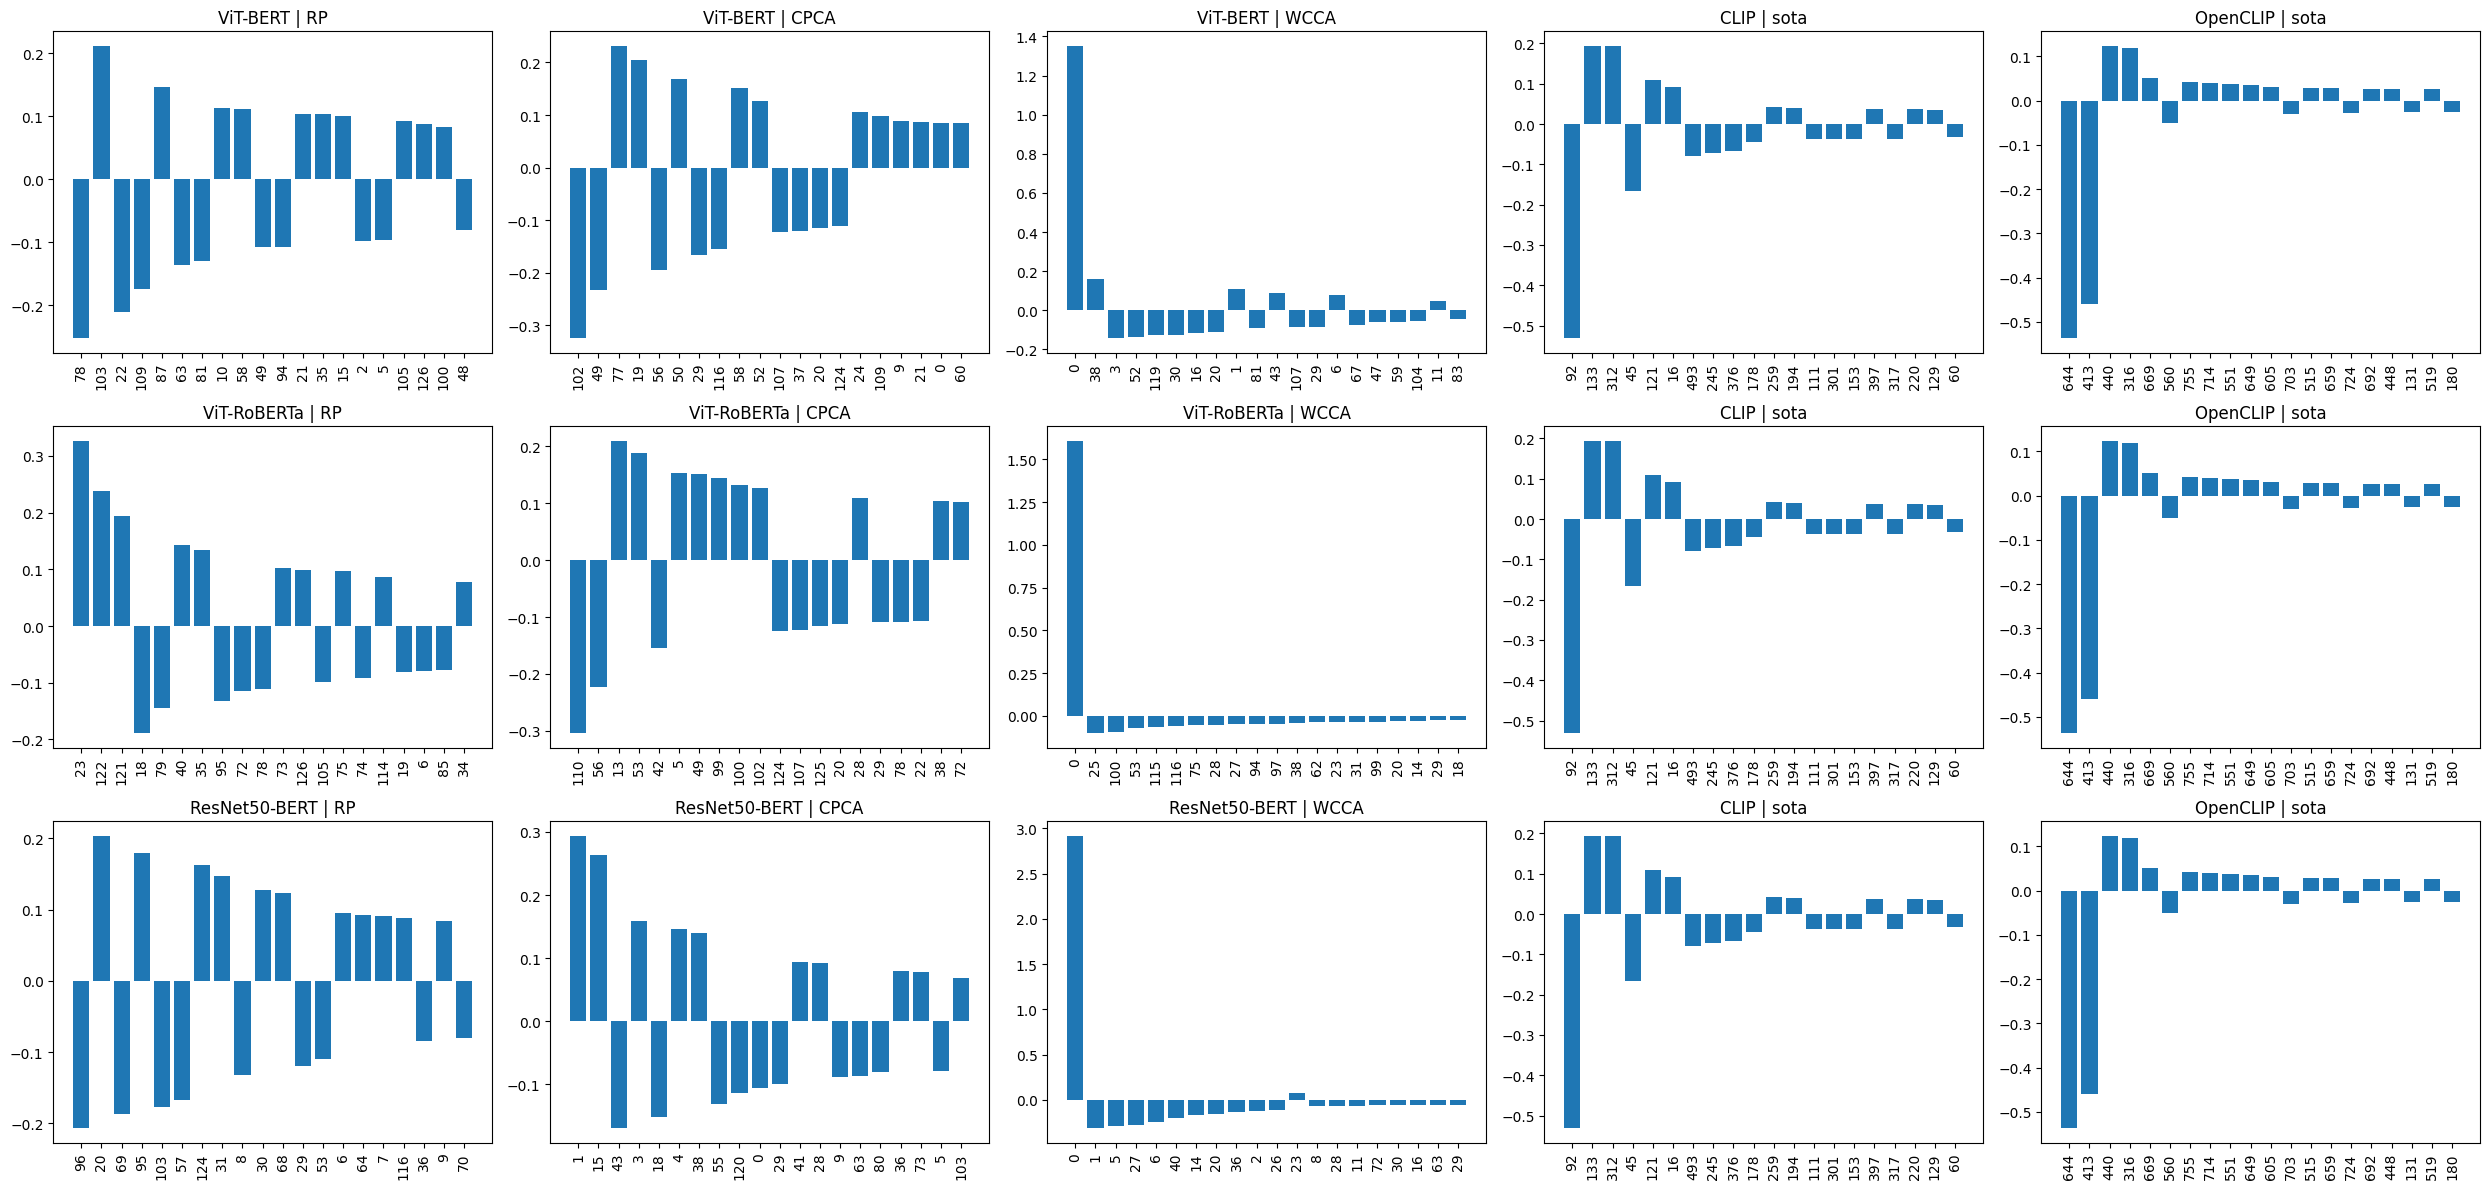

/tmp/ipykernel_580328/946625091.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


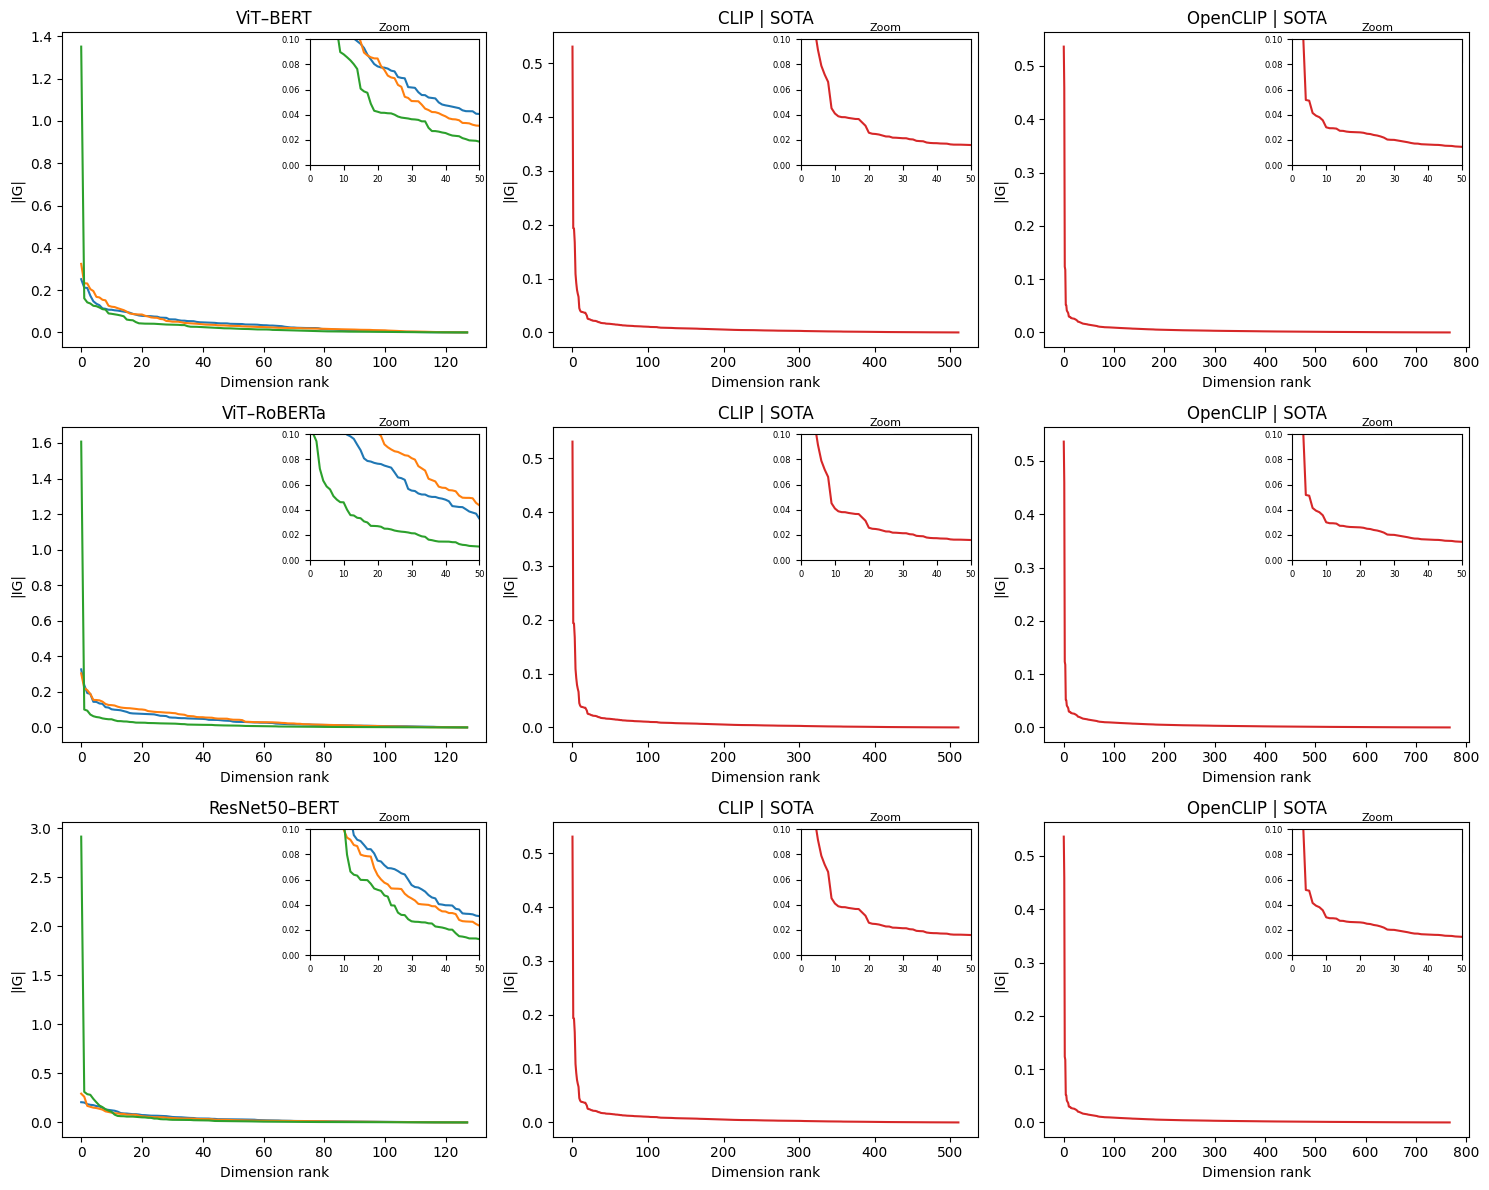

/tmp/ipykernel_580328/946625091.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


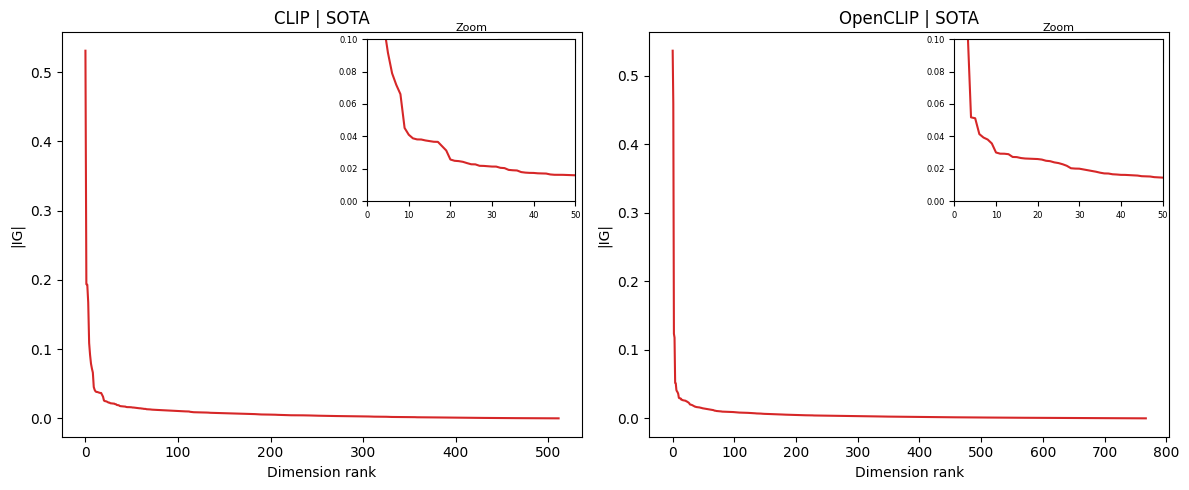

      Vision      Text Task Fusion Method          Mean       Std       Min  \
0        ViT      BERT  i2t   None     RP  4.656613e-10  0.062655 -0.251720   
1        ViT      BERT  i2t   None   CPCA -4.656613e-10  0.069515 -0.324199   
2        ViT      BERT  i2t   None   WCCA  4.656613e-10  0.126653 -0.142216   
3        ViT   RoBERTa  i2t   None     RP -2.328306e-10  0.064483 -0.188626   
4        ViT   RoBERTa  i2t   None   CPCA -9.313226e-10  0.071406 -0.304118   
5        ViT   RoBERTa  i2t   None   WCCA -2.328306e-09  0.143880 -0.100719   
6   ResNet50      BERT  i2t   None     RP -1.164153e-09  0.061684 -0.206413   
7   ResNet50      BERT  i2t   None   CPCA -2.328306e-10  0.059315 -0.168972   
8   ResNet50      BERT  i2t   None   WCCA -9.313226e-10  0.265561 -0.311769   
9       CLIP      CLIP  i2t   None   sota  1.164153e-10  0.030116 -0.530850   
10  OpenCLIP  OpenCLIP  i2t   None   sota -3.880511e-11  0.027275 -0.536274   

         Max   L1 Norm  
0   0.211962  5.412330  
1

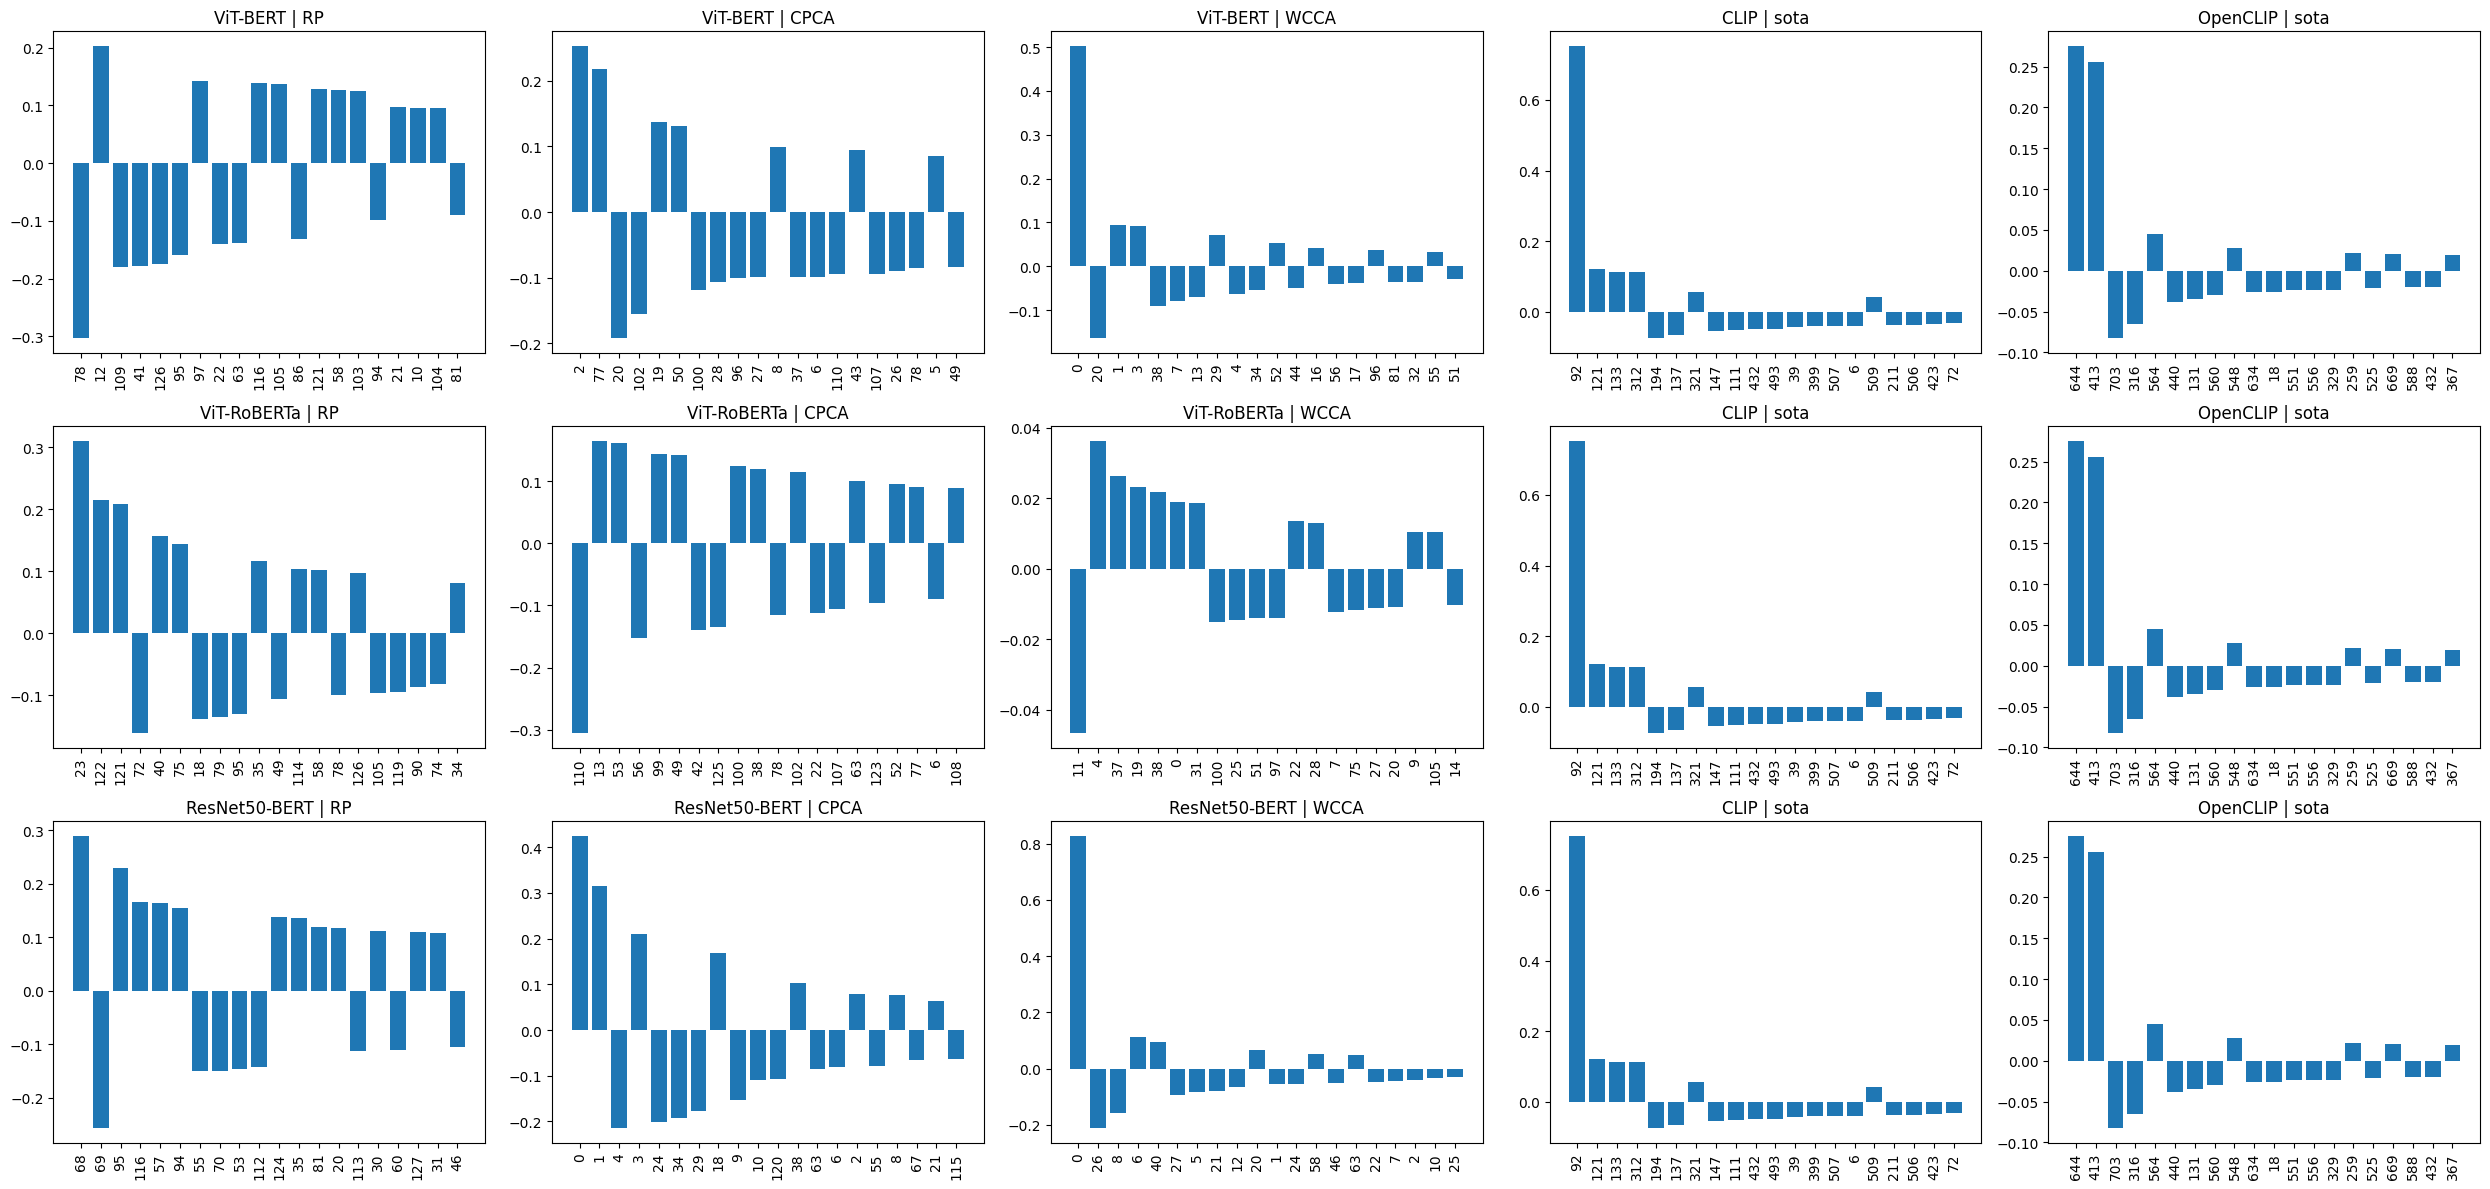

/tmp/ipykernel_580328/946625091.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


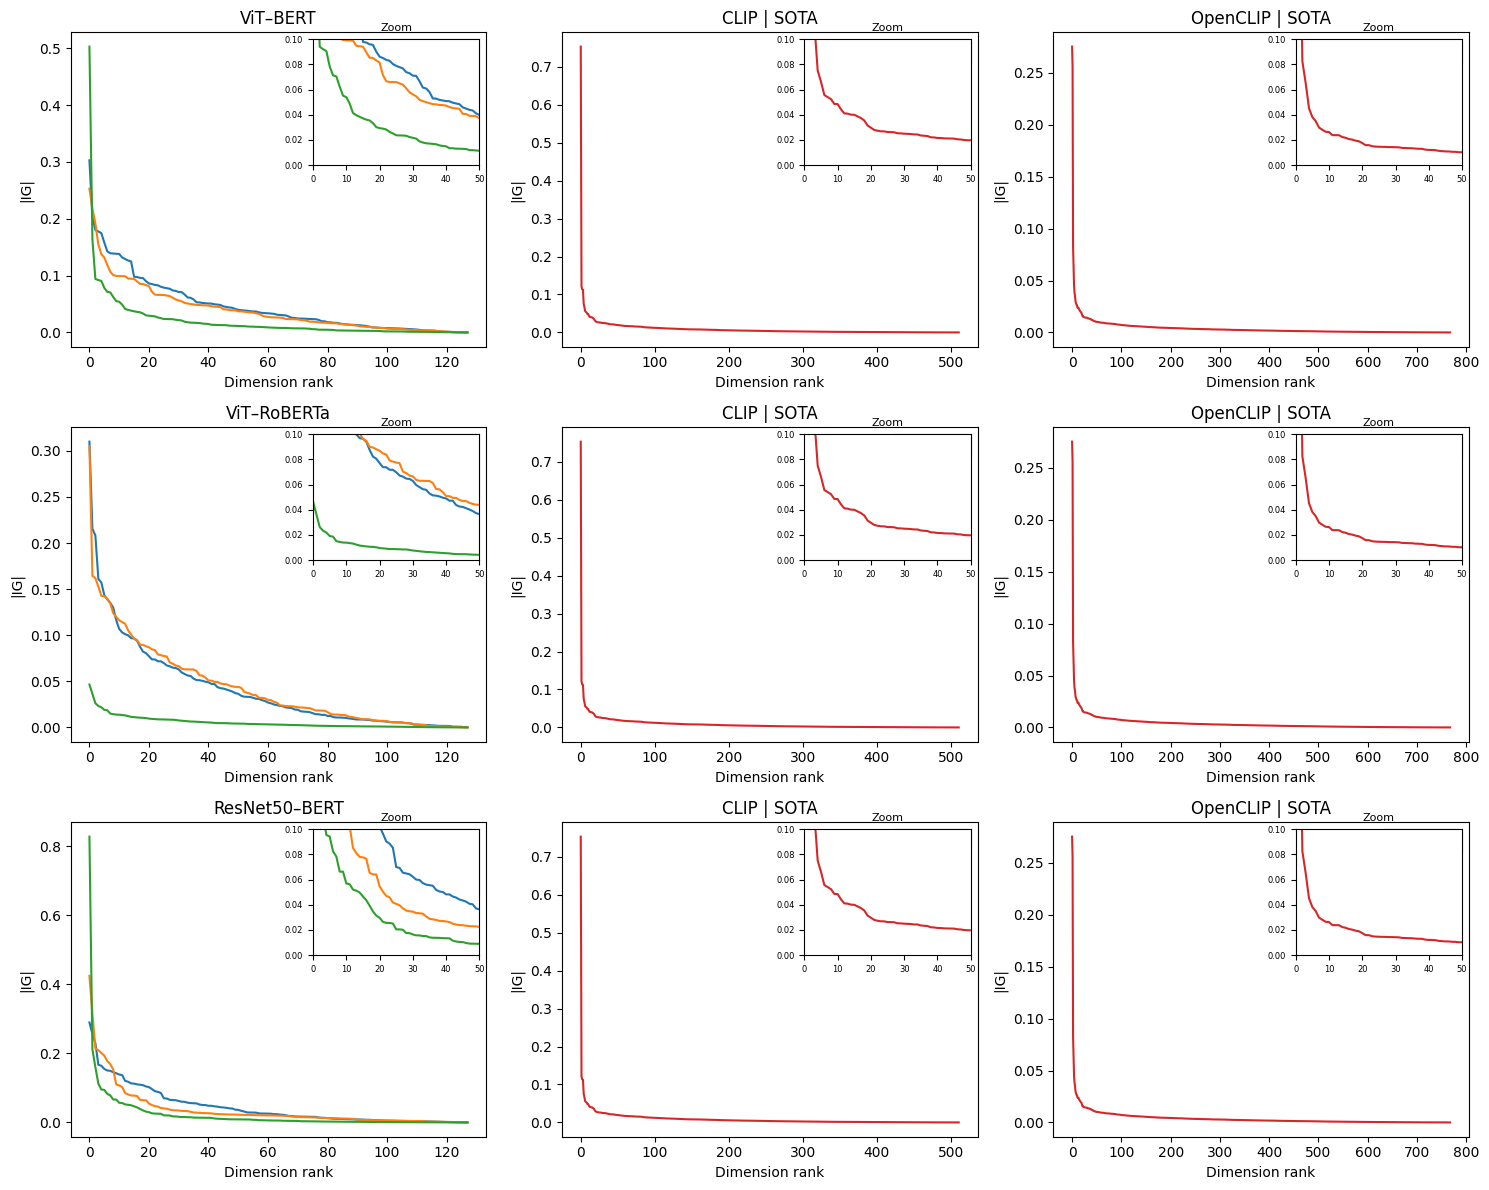

/tmp/ipykernel_580328/946625091.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


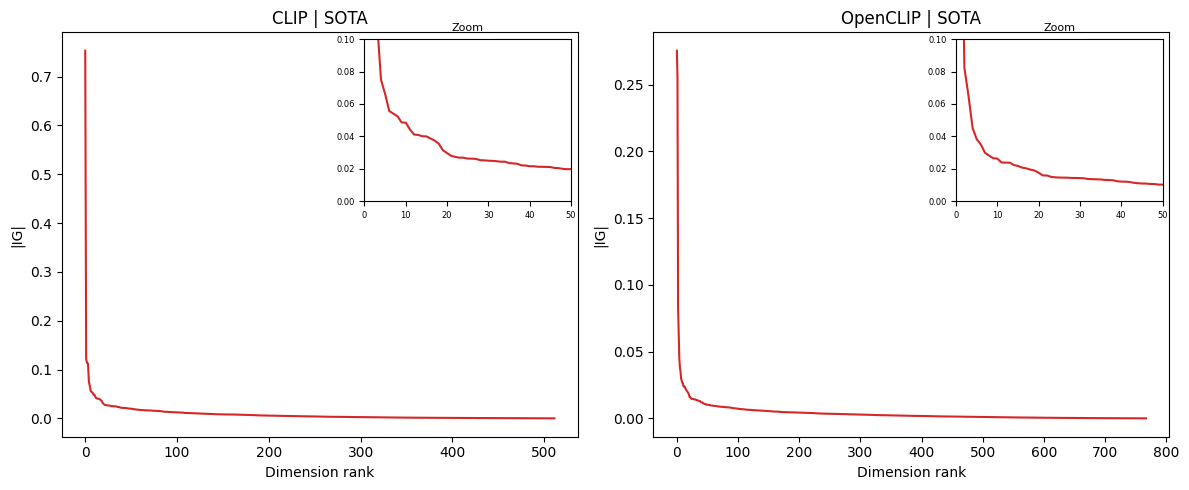

      Vision      Text Task Fusion Method          Mean       Std       Min  \
0        ViT      BERT  t2i   None     RP  1.396984e-09  0.069329 -0.302729   
1        ViT      BERT  t2i   None   CPCA -9.313226e-10  0.059533 -0.191797   
2        ViT      BERT  t2i   None   WCCA  4.656613e-10  0.052886 -0.163864   
3        ViT   RoBERTa  t2i   None     RP -4.656613e-10  0.064631 -0.161076   
4        ViT   RoBERTa  t2i   None   CPCA -6.984919e-10  0.064207 -0.305056   
5        ViT   RoBERTa  t2i   None   WCCA -2.328306e-10  0.008684 -0.046557   
6   ResNet50      BERT  t2i   None     RP -9.313226e-10  0.070675 -0.256177   
7   ResNet50      BERT  t2i   None   CPCA -9.313226e-10  0.071533 -0.214364   
8   ResNet50      BERT  t2i   None   WCCA -1.513399e-09  0.080982 -0.211904   
9       CLIP      CLIP  t2i   None   sota -1.164153e-10  0.036534 -0.075045   
10  OpenCLIP  OpenCLIP  t2i   None   sota  7.761022e-11  0.015246 -0.082484   

         Max   L1 Norm  
0   0.203049  6.005461  
1

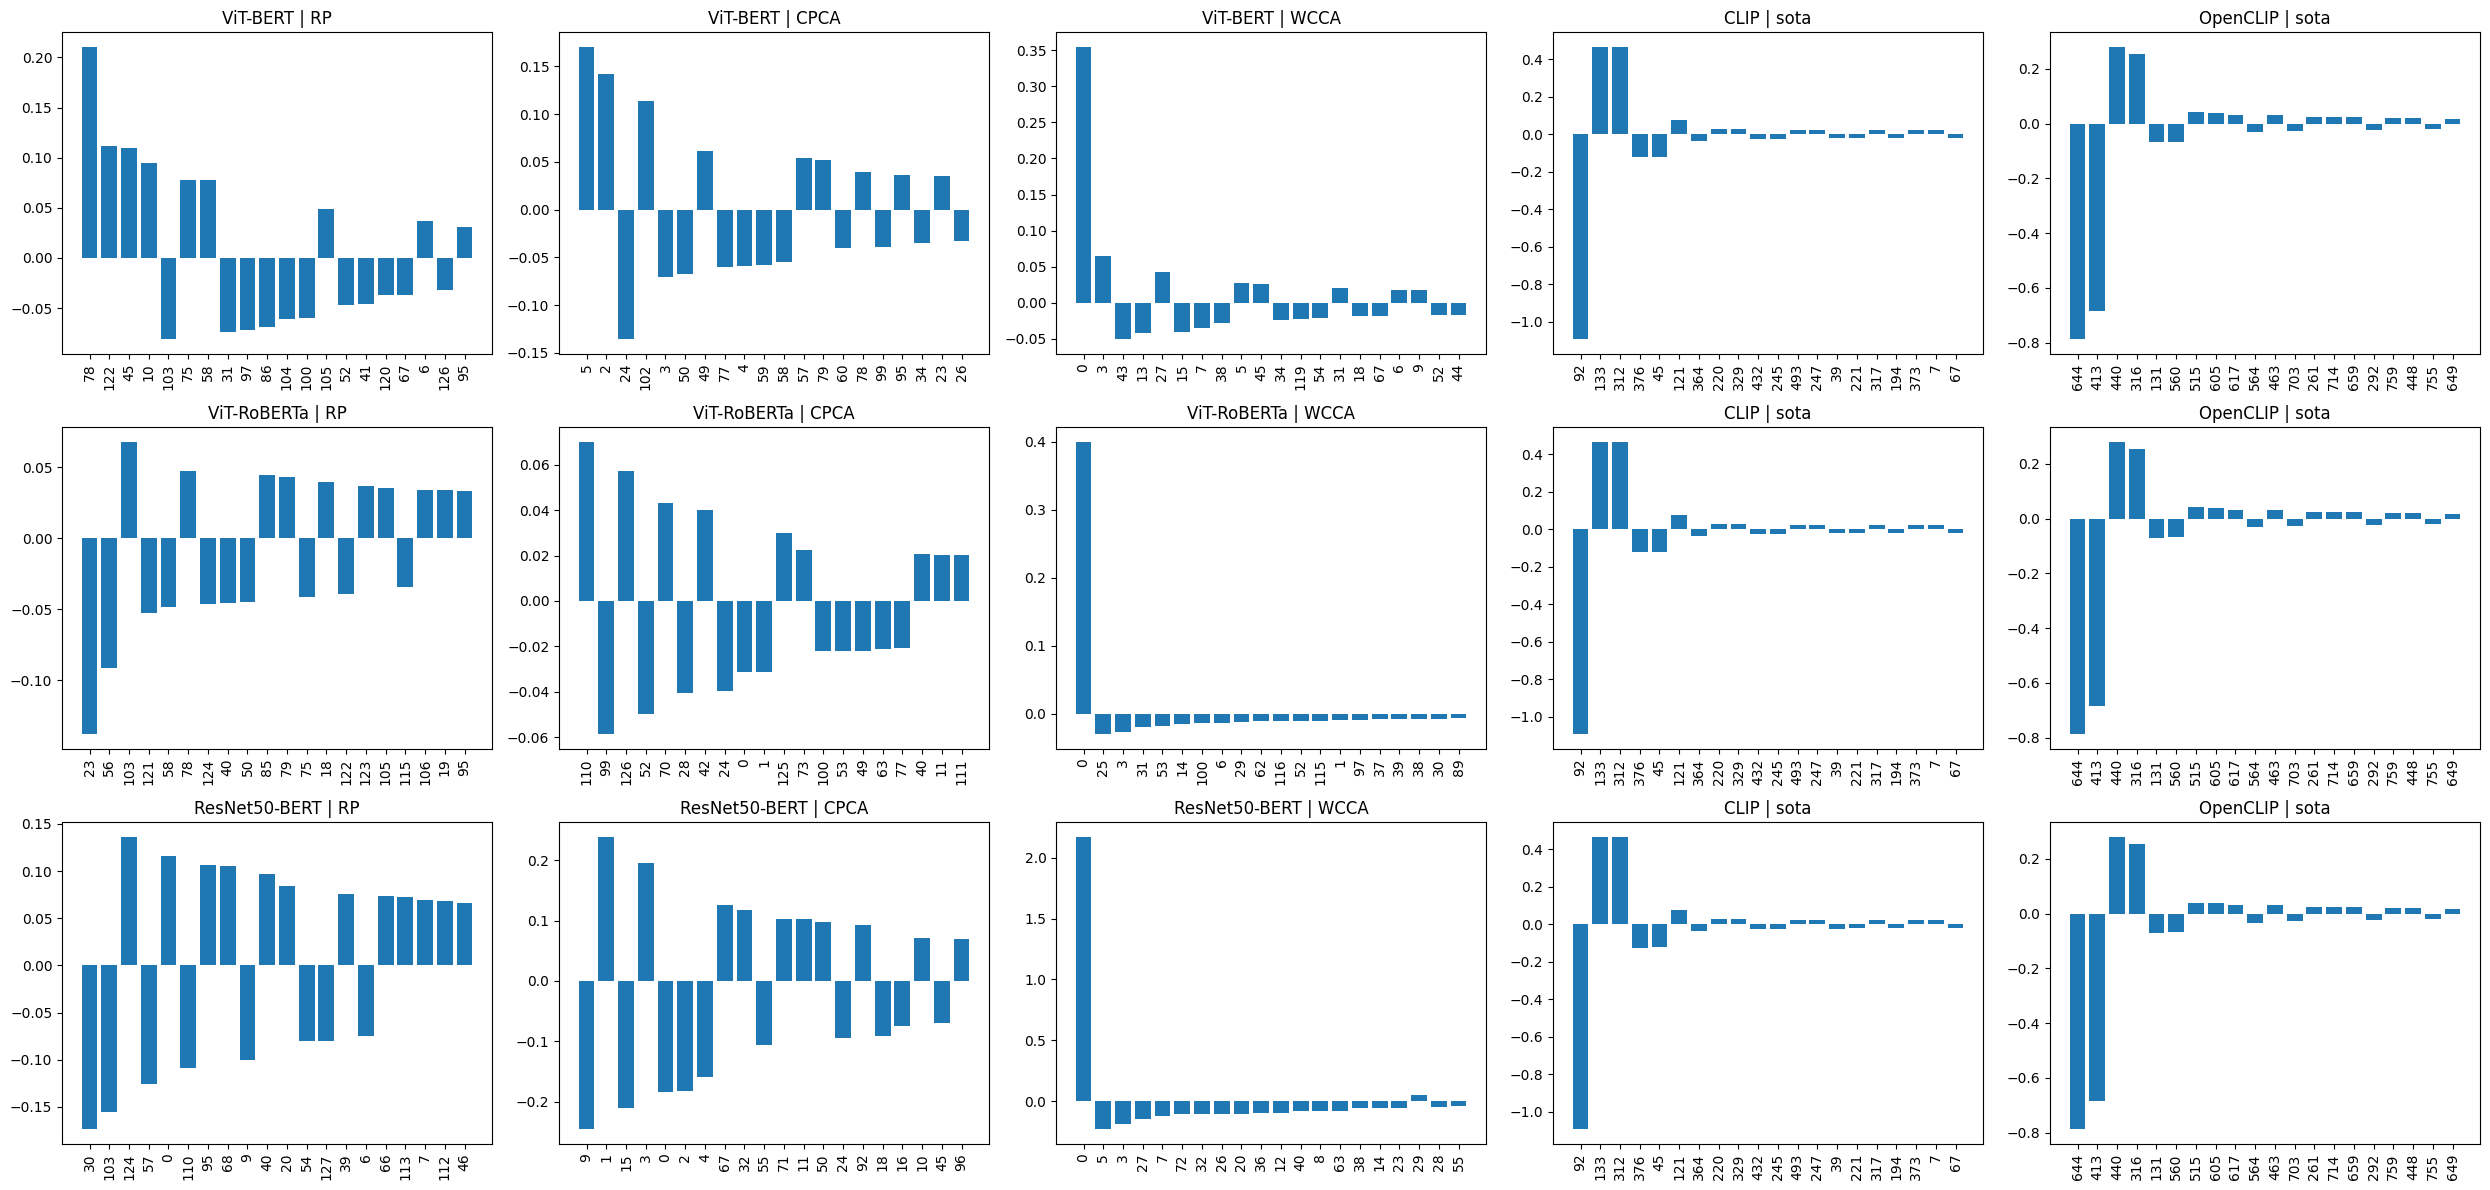

/tmp/ipykernel_580328/946625091.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


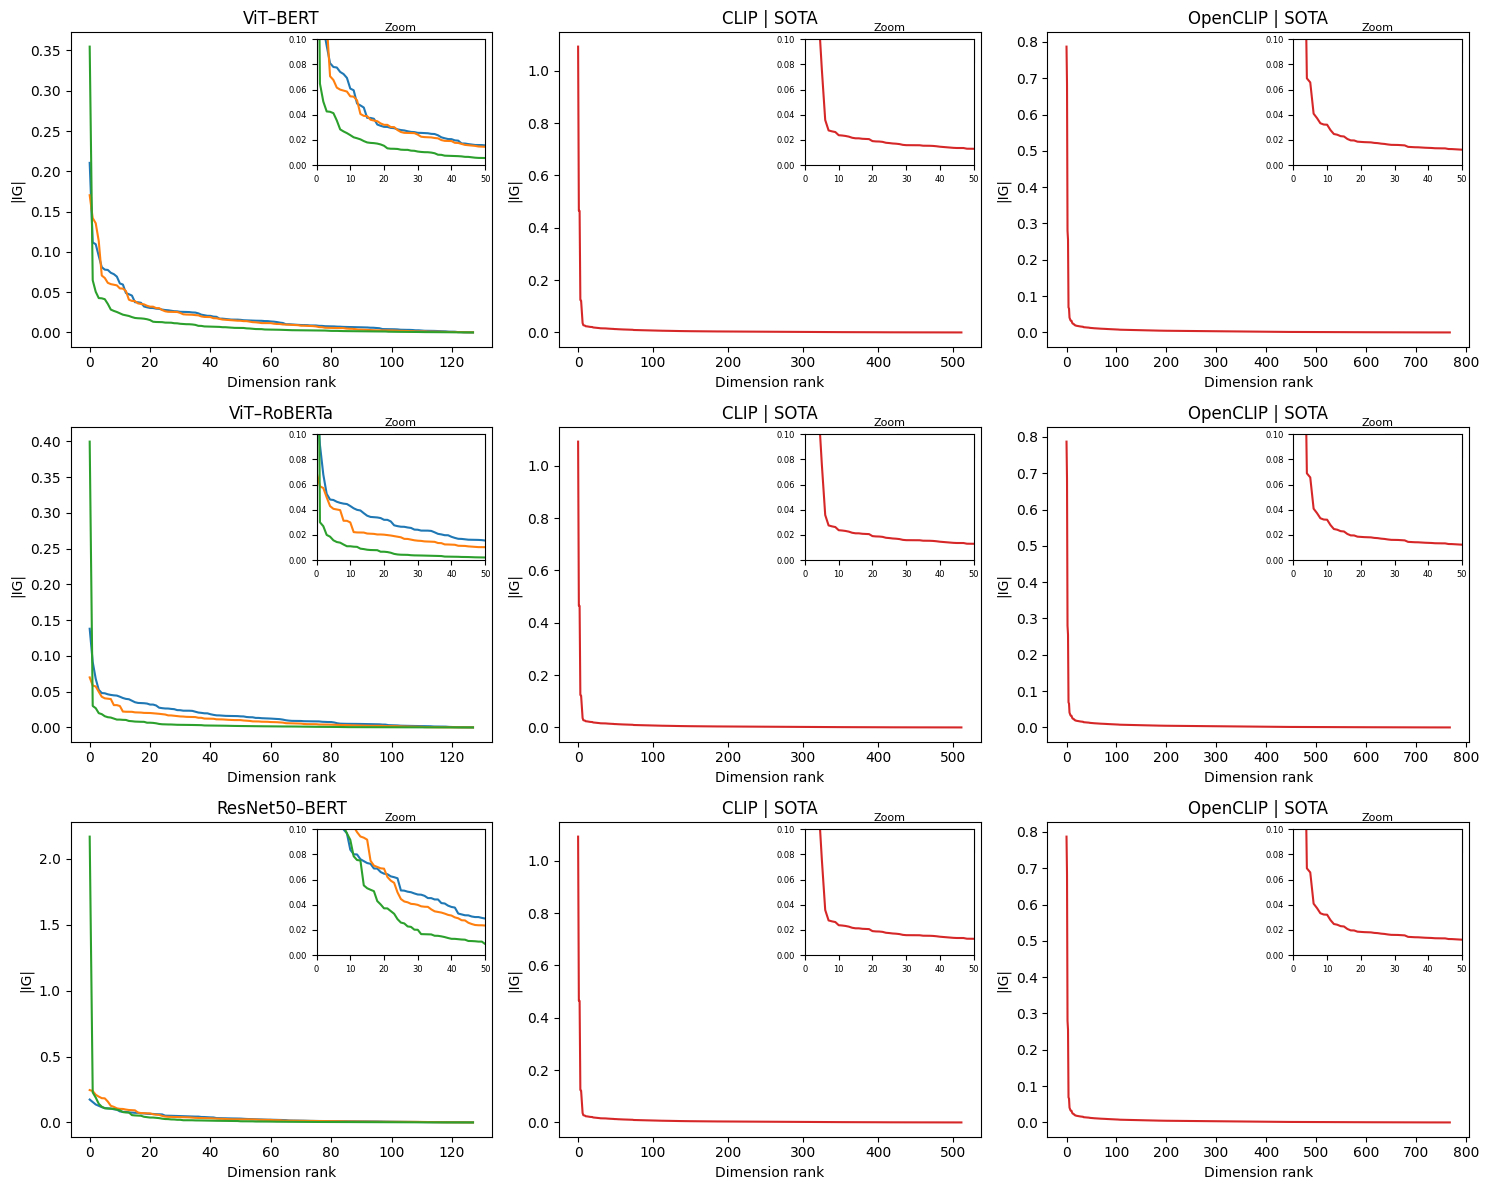

/tmp/ipykernel_580328/946625091.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


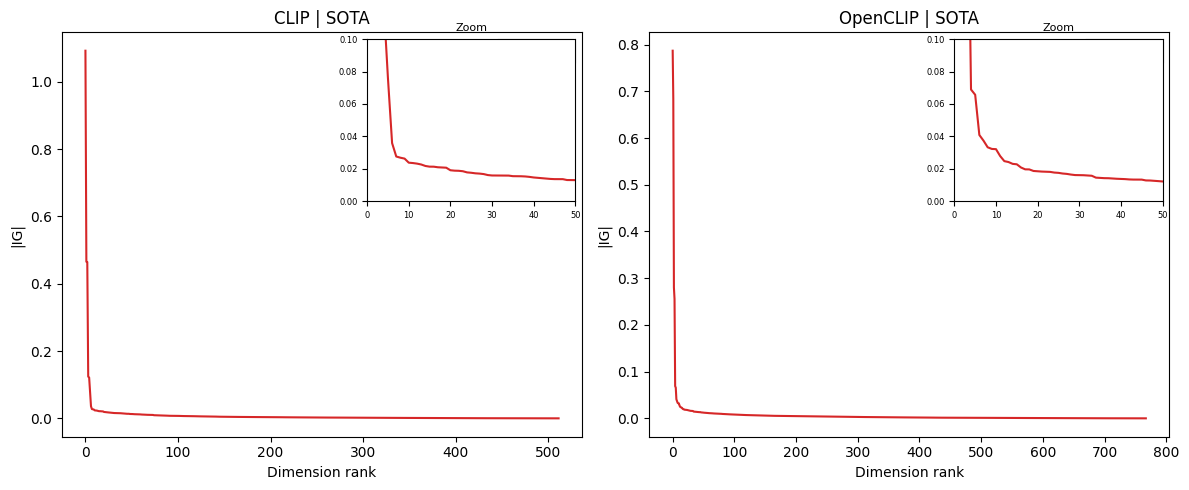

      Vision      Text Task Fusion Method          Mean       Std       Min  \
0        ViT      BERT  m2t    add     RP  1.979060e-09  0.034682 -0.080987   
1        ViT      BERT  m2t    add   CPCA -2.095476e-09  0.033206 -0.135481   
2        ViT      BERT  m2t    add   WCCA  2.328306e-09  0.034047 -0.050456   
3        ViT   RoBERTa  m2t    add     RP  1.164153e-10  0.025200 -0.137987   
4        ViT   RoBERTa  m2t    add   CPCA  6.984919e-10  0.016721 -0.058617   
5        ViT   RoBERTa  m2t    add   WCCA  1.396984e-09  0.035821 -0.030028   
6   ResNet50      BERT  m2t    add     RP  1.455192e-09  0.047275 -0.173628   
7   ResNet50      BERT  m2t    add   CPCA  0.000000e+00  0.060382 -0.245623   
8   ResNet50      BERT  m2t    add   WCCA  0.000000e+00  0.196311 -0.227817   
9       CLIP      CLIP  m2t    add   sota  3.492460e-10  0.057389 -1.092650   
10  OpenCLIP  OpenCLIP  m2t    add   sota  7.761022e-11  0.040634 -0.786895   

         Max   L1 Norm  
0   0.210440  2.633037  
1

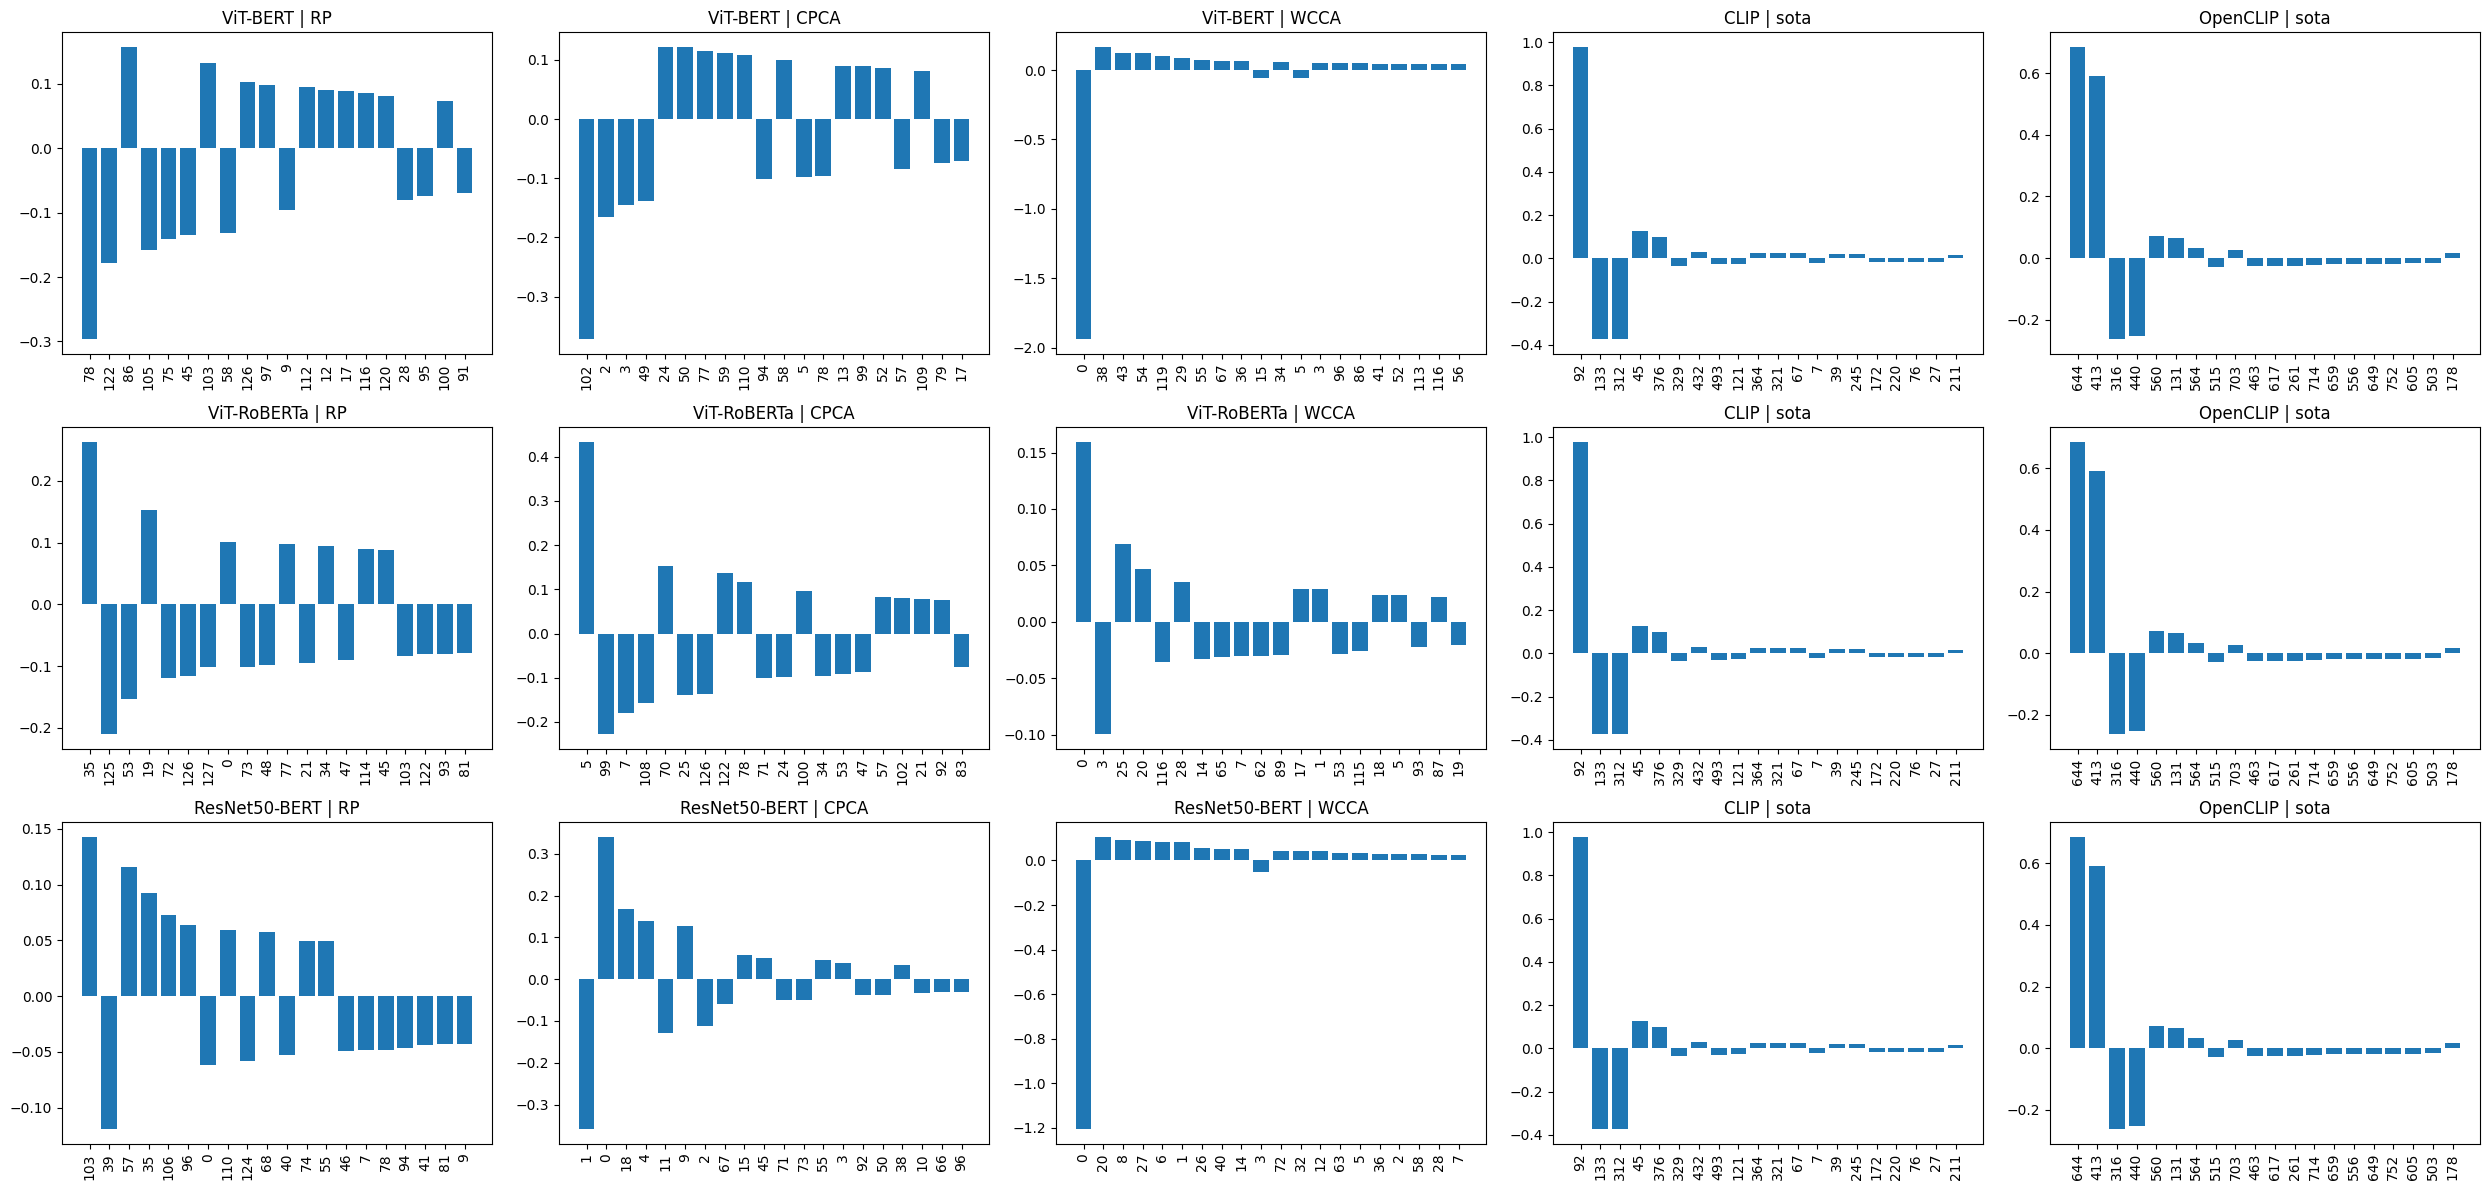

/tmp/ipykernel_580328/946625091.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


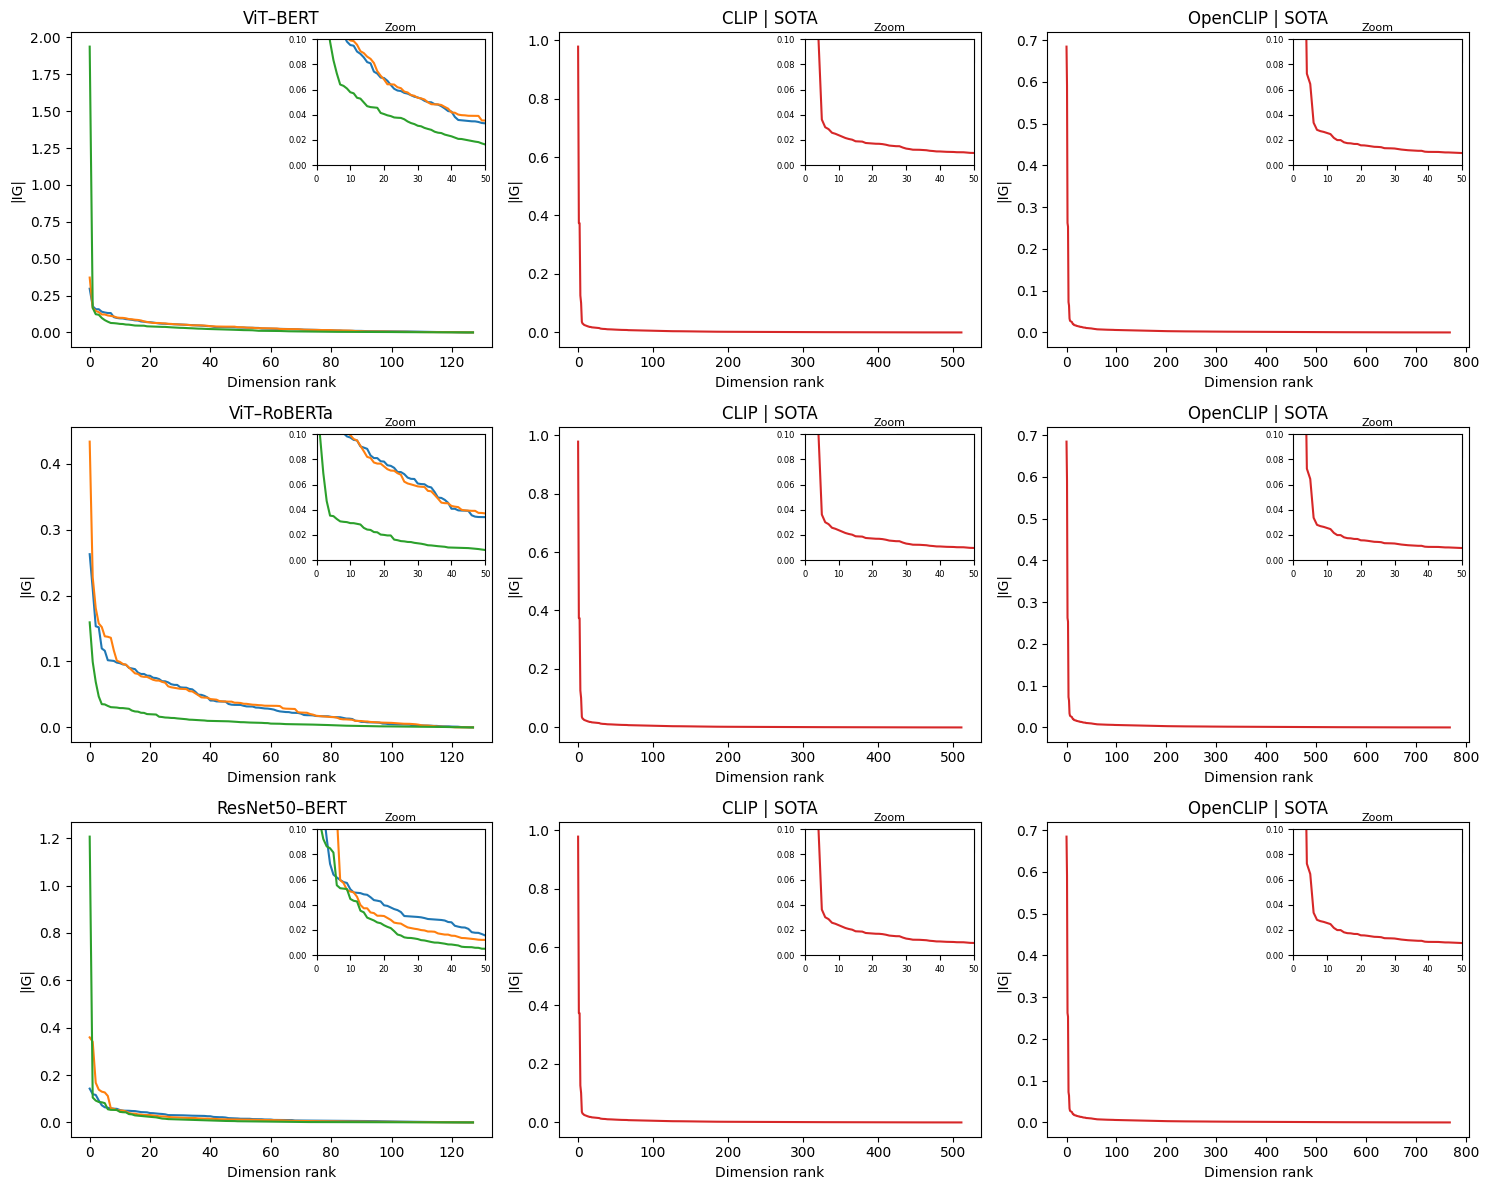

/tmp/ipykernel_580328/946625091.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


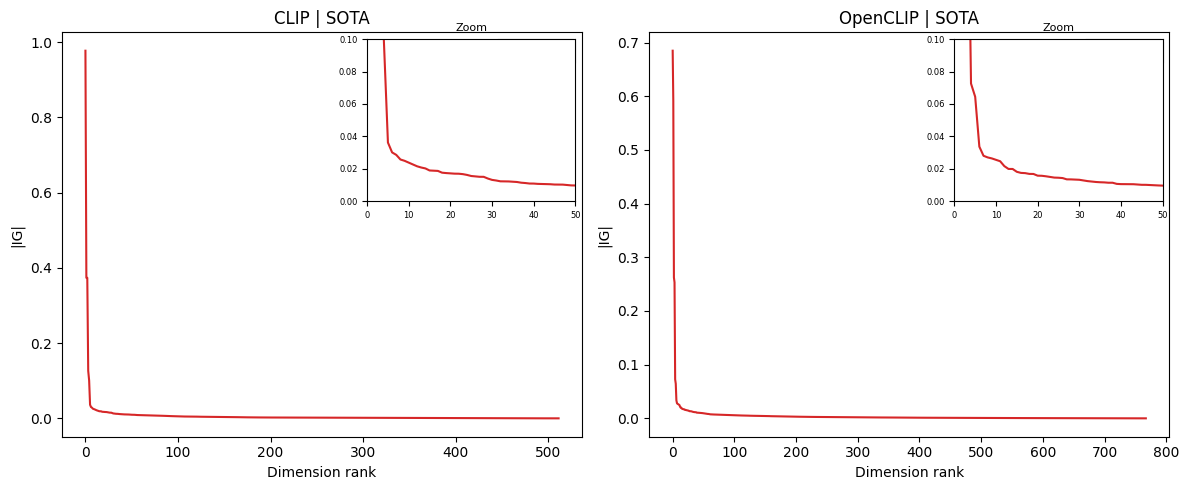

      Vision      Text Task Fusion Method          Mean       Std       Min  \
0        ViT      BERT  m2i    add     RP  1.164153e-09  0.057677 -0.296397   
1        ViT      BERT  m2i    add   CPCA -4.656613e-10  0.059806 -0.371943   
2        ViT      BERT  m2i    add   WCCA  1.862645e-09  0.174524 -1.937617   
3        ViT   RoBERTa  m2i    add     RP  4.656613e-10  0.057379 -0.209977   
4        ViT   RoBERTa  m2i    add   CPCA -4.656613e-10  0.067970 -0.227675   
5        ViT   RoBERTa  m2i    add   WCCA -8.731149e-11  0.021859 -0.099406   
6   ResNet50      BERT  m2i    add     RP  1.688022e-09  0.032063 -0.119228   
7   ResNet50      BERT  m2i    add   CPCA -1.746230e-09  0.054267 -0.359076   
8   ResNet50      BERT  m2i    add   WCCA  2.793968e-09  0.109127 -1.206319   
9       CLIP      CLIP  m2i    add   sota  5.820766e-10  0.049978 -0.373686   
10  OpenCLIP  OpenCLIP  m2i    add   sota -3.104409e-10  0.035693 -0.262358   

         Max   L1 Norm  
0   0.157324  4.824028  
1

In [404]:
for task in ["i2t", "t2i", "m2t", "m2i"]:
    plot_bar_grid_aligned_vs_sota(model_pairs, SOTA_MODELS, task)
    plot_sorted_curves_zoom_aligned_vs_sota(model_pairs, SOTA_MODELS, task)
    plot_sorted_curves_zoom_sota_only(SOTA_MODELS, task)
    print(compute_stats_all(model_pairs, SOTA_MODELS, task))

In [406]:
for task in ["m2t", "m2i"]:
    for f in ["add", "gated", "mul"]:
        print(compute_stats_all(model_pairs, SOTA_MODELS, task, f))

      Vision      Text Task Fusion Method          Mean       Std       Min  \
0        ViT      BERT  m2t    add     RP  1.979060e-09  0.034682 -0.080987   
1        ViT      BERT  m2t    add   CPCA -2.095476e-09  0.033206 -0.135481   
2        ViT      BERT  m2t    add   WCCA  2.328306e-09  0.034047 -0.050456   
3        ViT   RoBERTa  m2t    add     RP  1.164153e-10  0.025200 -0.137987   
4        ViT   RoBERTa  m2t    add   CPCA  6.984919e-10  0.016721 -0.058617   
5        ViT   RoBERTa  m2t    add   WCCA  1.396984e-09  0.035821 -0.030028   
6   ResNet50      BERT  m2t    add     RP  1.455192e-09  0.047275 -0.173628   
7   ResNet50      BERT  m2t    add   CPCA  0.000000e+00  0.060382 -0.245623   
8   ResNet50      BERT  m2t    add   WCCA  0.000000e+00  0.196311 -0.227817   
9       CLIP      CLIP  m2t    add   sota  3.492460e-10  0.057389 -1.092650   
10  OpenCLIP  OpenCLIP  m2t    add   sota  7.761022e-11  0.040634 -0.786895   

         Max   L1 Norm  
0   0.210440  2.633037  
1

In [411]:
# Ensure both DFs have the same columns
all_cols = sorted(set(quantus_results.columns) | set(quantus_sota_results.columns))

quantus_results = quantus_results.reindex(columns=all_cols)
quantus_sota_results = quantus_sota_results.reindex(columns=all_cols)

# Merge (row-wise)
quantus_all = pd.concat([quantus_results, quantus_sota_results], ignore_index=True)

# Reorder columns (optional but recommended)
first_cols = ["Vision", "Text", "Method", "Fusion", "Task"]
other_cols = [c for c in quantus_all.columns if c not in first_cols]

quantus_all = quantus_all[first_cols + other_cols]

# Sort for readability
quantus_all = quantus_all.sort_values(
    by=["Task", "Vision", "Text", "Method", "Fusion"],
    ignore_index=True
)

quantus_all = quantus_all[quantus_all["Task"].isin(["m2i"])].copy()
quantus_all

,Vision,Text,Method,Fusion,Task,Complexity,RankFaithfulnessMetric,Sparseness
11,CLIP,CLIP,sota,add,m2i,3.977799,NaN,0.813449
12,CLIP,CLIP,sota,gated,m2i,3.977799,NaN,0.813449
13,CLIP,CLIP,sota,mul,m2i,3.524121,NaN,0.891870
14,OpenCLIP,OpenCLIP,sota,add,m2i,4.480283,NaN,0.793714
15,OpenCLIP,OpenCLIP,sota,gated,m2i,4.480283,NaN,0.793714
16,OpenCLIP,OpenCLIP,sota,mul,m2i,2.918218,NaN,0.924174
17,ResNet50,BERT,CPCA,add,m2i,3.796144,0.0,0.702159
18,ResNet50,BERT,CPCA,gated,m2i,3.796144,0.0,0.702159
19,ResNet50,BERT,CPCA,mul,m2i,2.653971,NaN,0.876779
20,ResNet50,BERT,RP,add,m2i,4.309996,0.0,0.558502
